# Airbnb Amsterdam



This is my notebook for the Amsterdam Airbnb project. The goal I started with was to predict a fair nightly price for a listing from the things I already know about it, like its size, room type, location and amenities.

It did not work as well as I hoped. The price models stayed weak, so in the second half I changed the goal: instead of predicting a price I group the listings into market segments and describe them. I kept the parts that did not work in the notebook on purpose, so the steps and the reason I changed direction stay visible.

## Data Cleaning Notebook

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:


listings_path = "data/raw/march 2025/calendar.csv"
calendar_path = "data/raw/march 2025/listings-main.csv"

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 180)



## Load raw data

In [3]:

# Load raw CSVs
listings_raw_df = pd.read_csv(calendar_path)
calendar_raw_df = pd.read_csv(listings_path)

listings_raw_df


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2.818000e+03,https://www.airbnb.com/rooms/2818,2.025030e+13,3/3/25,city scrape,Quiet Garden View Room & Super Fast Wi-Fi,Quiet Garden View Room & Super Fast Wi-Fi,"Indische Buurt (""Indies Neighborhood"") is a ne...",https://a0.muscache.com/pictures/10272854/8dcc...,3159,https://www.airbnb.com/users/show/3159,Daniel,9/24/08,"Amsterdam, Netherlands","Upon arriving in Amsterdam, one can imagine as...",within an hour,100%,100%,t,https://a0.muscache.com/im/users/3159/profile_...,https://a0.muscache.com/im/users/3159/profile_...,Indische Buurt,1.0,1.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Oostelijk Havengebied - Indische Buurt,NaN,52.364350,4.943580,Private room in condo,Private room,2,1.5,1.5 shared baths,1.0,2.0,"[""PH neutral and dermatologically tested body ...",$66.00,3,28,3.0,3.0,1125.0,1125.0,3.0,1125.0,NaN,t,10,10,10,10,3/3/25,398,31,0,10,32,242,15972.0,3/30/09,1/3/25,4.91,4.93,4.99,4.97,4.98,4.73,4.80,0363 5F3A 5684 6750 D14D,f,1,0,1,0,2.05
1,2.788600e+04,https://www.airbnb.com/rooms/27886,2.025030e+13,3/3/25,previous scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,https://www.airbnb.com/users/show/97647,Flip,3/23/10,"Amsterdam, Netherlands","Marjan works in ""eye"" the dutch filmmuseum, an...",within an hour,100%,98%,t,https://a0.muscache.com/im/users/97647/profile...,https://a0.muscache.com/im/users/97647/profile...,Westelijke Eilanden,1.0,1.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Centrum-West,NaN,52.387610,4.891880,Private room in houseboat,Private room,2,NaN,1.5 baths,1.0,NaN,"[""Heating - split type ductless system"", ""Priv...",NaN,3,356,3.0,3.0,30.0,30.0,3.0,30.0,NaN,t,5,9,9,88,3/3/25,294,27,1,88,26,211,NaN,1/9/12,2/17/25,4.92,4.90,4.94,4.95,4.92,4.89,4.77,0363 974D 4986 7411 88D8,f,1,0,1,0,1.84
2,2.887100e+04,https://www.airbnb.com/rooms/28871,2.025030e+13,3/3/25,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,Edwin,5/13/10,"Amsterdam, Netherlands",Hi,within an hour,100%,99%,t,https://a0.muscache.com/im/pictures/user/9986b...,https://a0.muscache.com/im/pictures/user/9986b...,Amsterdam Centrum,2.0,2.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Centrum-West,NaN,52.367750,4.890920,Private room in rental unit,Private room,2,1.

## Shapes

In [4]:

listings_raw_df.shape, calendar_raw_df.shape


((10075, 79), (3673991, 7))

## Schema / dtypes

In [4]:

listings_raw_df.info()
calendar_raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10075 entries, 0 to 10074
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10075 non-null  float64
 1   listing_url                                   10075 non-null  object 
 2   scrape_id                                     10075 non-null  float64
 3   last_scraped                                  10075 non-null  object 
 4   source                                        10075 non-null  object 
 5   name                                          10075 non-null  object 
 6   description                                   9729 non-null   object 
 7   neighborhood_overview                         5332 non-null   object 
 8   picture_url                                   10075 non-null  object 
 9   host_id                                       10075 non-null 

## Numeric summary

In [6]:

print(listings_raw_df.describe())
print(calendar_raw_df.describe())


                 id     scrape_id       host_id  host_listings_count  host_total_listings_count  neighbourhood_group_cleansed      latitude     longitude  accommodates  \
count  1.007500e+04  1.007500e+04  1.007500e+04         10058.000000               10058.000000                           0.0  10075.000000  10075.000000  10075.000000   
mean   5.207374e+17  2.025030e+13  1.279838e+08             3.570889                   5.802645                           NaN     52.366567      4.889464      2.927444   
std    5.197561e+17  0.000000e+00  1.700389e+08            33.064417                  75.902377                           NaN      0.017197      0.035186      1.305597   
min    2.818000e+03  2.025030e+13  3.159000e+03             1.000000                   1.000000                           NaN     52.290276      4.755870      1.000000   
25%    2.388150e+07  2.025030e+13  1.244407e+07             1.000000                   1.000000                           NaN     52.355675      

All values in normal range

## Missing values (percentage per column)

In [5]:

miss_listings = listings_raw_df.isna().mean().sort_values(ascending=False) * 100
miss_calendar = calendar_raw_df.isna().mean().sort_values(ascending=False) * 100
miss_listings, miss_calendar


(calendar_updated                100.000000
 neighbourhood_group_cleansed    100.000000
 host_neighbourhood               71.533499
 host_about                       47.245658
 neighbourhood                    47.076923
                                    ...    
 maximum_nights                    0.000000
 availability_30                   0.000000
 availability_60                   0.000000
 availability_90                   0.000000
 amenities                         0.000000
 Length: 79, dtype: float64,
 adjusted_price    100.000000
 minimum_nights      0.000027
 maximum_nights      0.000027
 listing_id          0.000000
 date                0.000000
 available           0.000000
 price               0.000000
 dtype: float64)

In [6]:
miss_ = listings_raw_df["neighbourhood_cleansed"].isna().mean() * 100
print(miss_)

0.0


100% missing, drop now or don’t use:
calendar_updated, neighbourhood_group_cleansed (in listings) and adjusted_price (in calendar)
There’s no data there.

72% missing:
host_neighbourhood.
Not useful,drop.

47% missing, text/optional fields, clean later if needed:
host_about, neighbourhood, neighborhood_overview.
These are descriptions that not needed for price.

39-41% missing:
price (from listings), beds, bathrooms, estimated_revenue_l365d.
Keep beds/bathrooms with NaN for now and drop estimated_revenue_l365d as not needed for predictions.

11 -21% missing :
host_response_time, host_response_rate, host_acceptance_rate,review_scores_*, first_review, last_review
Keep them for now.

## Calendar window

In [9]:

calendar_raw_df = calendar_raw_df.copy()
if "date" in calendar_raw_df.columns:
    calendar_raw_df["date"] = pd.to_datetime(calendar_raw_df["date"], errors="coerce")
(calendar_raw_df["date"].min(), calendar_raw_df["date"].quantile(0.25), calendar_raw_df["date"].median(), calendar_raw_df["date"].quantile(0.75), calendar_raw_df["date"].max())


(Timestamp('2025-03-02 00:00:00'),
 Timestamp('2025-06-01 00:00:00'),
 Timestamp('2025-09-01 00:00:00'),
 Timestamp('2025-12-01 00:00:00'),
 Timestamp('2026-03-02 00:00:00'))

The calendar covers 02/03/2025 to 02/03/2026, but most of it is placeholder rows with the same repeated price, so it is not useful for prediction.

## Join keys sanity (listings id and calendar listing id)

In [7]:

overlap_ratio = None
if "id" in listings_raw_df.columns and "listing_id" in calendar_raw_df.columns:
    overlap_ratio = pd.Series(calendar_raw_df["listing_id"].unique()).isin(listings_raw_df["id"].unique()).mean()
overlap_ratio


np.float64(0.4738724418835685)

---
# Data Cleaning


## Create working copy

In [8]:

df = listings_raw_df.copy()
calendar_raw_df = calendar_raw_df.copy()


## Drop irrelevant or mostly-missing columns

In [9]:
keep_cols_target = [
    "id",
    "latitude",
    "longitude",
    "price",
    "property_type",
    "room_type",
    "accommodates",
    "neighbourhood_cleansed",
    "bathrooms_text",
    "bedrooms",
    "beds",
    "amenities",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "estimated_occupancy_l365d",
    "instant_bookable",
]

keep_cols = [c for c in keep_cols_target if c in df.columns]
missing   = [c for c in keep_cols_target if c not in df.columns]

cols_to_drop = [c for c in df.columns if c not in keep_cols]

before = df.shape
df = df.drop(columns=cols_to_drop, errors="ignore")

df = df[keep_cols].copy()
after = df.shape

print(f"Missing columns: {missing}")
print(f"Dropped {len(cols_to_drop)} columns. Shape: {before} - {after}")

df

Missing columns: []
Dropped 62 columns. Shape: (10075, 79) - (10075, 17)


,id,latitude,longitude,price,property_type,room_type,accommodates,neighbourhood_cleansed,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,availability_365,estimated_occupancy_l365d,instant_bookable
0,2.818000e+03,52.364350,4.943580,$66.00,Private room in condo,Private room,2,Oostelijk Havengebied - Indische Buurt,1.5 shared baths,1.0,2.0,"[""PH neutral and dermatologically tested body ...",3,28,10,242,f
1,2.788600e+04,52.387610,4.891880,NaN,Private room in houseboat,Private room,2,Centrum-West,1.5 baths,1.0,NaN,"[""Heating - split type ductless system"", ""Priv...",3,356,88,211,f
2,2.887100e+04,52.367750,4.890920,$75.00,Private room in rental unit,Private room,2,Centrum-West,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Hangers"", ""Smoke alarm"", ""Cl...",2,730,84,255,f
3,2.905100e+04,52.365840,4.891110,$59.00,Private room in condo,Private room,2,Centrum-Oost,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Hangers"", ""Smoke alarm"", ""Pr...",2,730,84,255,f
4,4.439100e+04,52.371680,4.914710,NaN,Entire rental unit,Entire home/apt,4,Centrum-Oost,1.5 baths,2.0,NaN,"[""Private entrance"", ""Paid parking off premise...",3,730,0,0,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10070,1.366550e+18,52.363930,4.890370,$355.00,Entire rental unit,Entire home/apt,2,Centrum-Oost,1 bath,1.0,1.0,"[""Hangers"", ""Heating"", ""Hot water"", ""TV"", ""Wif...",2,30,58,0,f
10071,1.366680e+18,52.370945,4.865289,$144.00,Entire rental unit,Entire home/apt,2,De Baarsjes - Oud-West,1 bath,1.0,1.0,"[""Private entrance"", ""Coffee maker: espresso m...",1,365,27,0,t
10072,1.366710e+18,52.355660,4.833230,$138.00,Entire rental unit,Entire home/apt,3,Slotervaart,1 bath,1.0,1.0,"[""Smoke alarm"", ""Washer"", ""Wifi"", ""TV"", ""Outdo...",2,365,102,0,f
10073,1.367340e+18,52.375430,4.894620,$126.00,Entire rental unit,Entire home/apt,2,Centrum-West,1 bath,1.0,1.0,"[""Smoke alarm"", ""Mini fridge"", ""Hot water"", ""W...",1,365,5,0,t


Explanation of chosen columns:
**Columns to keep:**
id
latitude
longitude
property_type
room_type
accommodates
bathrooms
bedrooms
beds
amenities
minimum_nights
maximum_nights
availability_365
estimated_occupancy_l365d
instant_bookable

Columns to drop:
price
calendar price will be used instead due to NaN values

bathrooms
too many missing value compared to bathrooms_text, which also can give me more info about bathrooms than just number

listing_url, picture_url, source, host_url, host_thumbnail_url, host_picture_url
Administrative fields, no predictive value.

neighbourhood, neighborhood_overview, host_about, host_neighbourhood, host_location,alendar_updated, neighbourhood_group_cleansed, estimated_revenue_l365d
Too many NaNs or duplicate the information already covered by location or amenities.

review_scores_value, first_review, last_review, reviews_per_month, number_of_reviews
Poor predictive signal(scores mostly between 4.4-5.0)

host_response_time, host_response_rate, host_acceptance_rate, host_is_superhost,
host_verifications, host_has_profile_pic, host_identity_verified, host_since, host_name, host_id
No predictive value and lots of missing data.

host_listings_count, host_total_listings_count, calculated_host_listings_count
Describe host scale, not proper characteristics.

has_availability, calendar_last_scraped, availability_30, availability_60, availability_90, availability_eoy
Redundant features, Im keeping only availability_365.

bathrooms_text - redundant, numeric bathrooms is better.

license, scrape_id, last_scraped, name
No value for modeling.

## Combine price from calendar to listings


In [10]:
calendar_raw_df["price"] = (
    calendar_raw_df["price"].astype(str)
    .str.replace("\u00A0", "", regex=False)
    .str.replace(r"[^\d,.\-]", "", regex=True)
    .str.replace(r"(?<=\d),(?=\d{1,2}$)", ".", regex=True)
    .str.replace(",", "", regex=True)
    .astype(float)
)

_cal = calendar_raw_df.reset_index(names="__row__")
cal_first = (
    _cal.dropna(subset=["listing_id", "price"])
        .sort_values("__row__")
        .drop_duplicates(subset=["listing_id"], keep="first")
        [["listing_id", "price"]]
        .rename(columns={"price": "price_cal"})
)

df = df.merge(cal_first, how="left", left_on="id", right_on="listing_id").drop(columns=["listing_id"])

df["price"] = (
    calendar_raw_df["price"].astype(str)
    .str.replace("\u00A0", "", regex=False)
    .str.replace(r"[^\d,.\-]", "", regex=True)
    .str.replace(r"(?<=\d),(?=\d{1,2}$)", ".", regex=True)
    .str.replace(",", "", regex=True)
    .astype(float)
)

df["price"] = df["price_cal"].combine_first(df["price"])
df = df.drop(columns=["price_cal"])

df

,id,latitude,longitude,price,property_type,room_type,accommodates,neighbourhood_cleansed,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,availability_365,estimated_occupancy_l365d,instant_bookable
0,2.818000e+03,52.364350,4.943580,89.0,Private room in condo,Private room,2,Oostelijk Havengebied - Indische Buurt,1.5 shared baths,1.0,2.0,"[""PH neutral and dermatologically tested body ...",3,28,10,242,f
1,2.788600e+04,52.387610,4.891880,155.0,Private room in houseboat,Private room,2,Centrum-West,1.5 baths,1.0,NaN,"[""Heating - split type ductless system"", ""Priv...",3,356,88,211,f
2,2.887100e+04,52.367750,4.890920,79.0,Private room in rental unit,Private room,2,Centrum-West,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Hangers"", ""Smoke alarm"", ""Cl...",2,730,84,255,f
3,2.905100e+04,52.365840,4.891110,55.0,Private room in condo,Private room,2,Centrum-Oost,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Hangers"", ""Smoke alarm"", ""Pr...",2,730,84,255,f
4,4.439100e+04,52.371680,4.914710,240.0,Entire rental unit,Entire home/apt,4,Centrum-Oost,1.5 baths,2.0,NaN,"[""Private entrance"", ""Paid parking off premise...",3,730,0,0,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10070,1.366550e+18,52.363930,4.890370,180.0,Entire rental unit,Entire home/apt,2,Centrum-Oost,1 bath,1.0,1.0,"[""Hangers"", ""Heating"", ""Hot water"", ""TV"", ""Wif...",2,30,58,0,f
10071,1.366680e+18,52.370945,4.865289,180.0,Entire rental unit,Entire home/apt,2,De Baarsjes - Oud-West,1 bath,1.0,1.0,"[""Private entrance"", ""Coffee maker: espresso m...",1,365,27,0,t
10072,1.366710e+18,52.355660,4.833230,180.0,Entire rental unit,Entire home/apt,3,Slotervaart,1 bath,1.0,1.0,"[""Smoke alarm"", ""Washer"", ""Wifi"", ""TV"", ""Outdo...",2,365,102,0,f
10073,1.367340e+18,52.375430,4.894620,180.0,Entire rental unit,Entire home/apt,2,Centrum-West,1 bath,1.0,1.0,"[""Smoke alarm"", ""Mini fridge"", ""Hot water"", ""W...",1,365,5,0,t


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10075 entries, 0 to 10074
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10075 non-null  float64
 1   latitude                   10075 non-null  float64
 2   longitude                  10075 non-null  float64
 3   price                      10075 non-null  float64
 4   property_type              10075 non-null  object 
 5   room_type                  10075 non-null  object 
 6   accommodates               10075 non-null  int64  
 7   neighbourhood_cleansed     10075 non-null  object 
 8   bathrooms_text             10067 non-null  object 
 9   bedrooms                   9783 non-null   float64
 10  beds                       5925 non-null   float64
 11  amenities                  10075 non-null  object 
 12  minimum_nights             10075 non-null  int64  
 13  maximum_nights             10075 non-null  int

Beds is missing for about 40% of the rows. That is a lot to lose if I just drop those rows, so instead I will fill the missing values later.

In [15]:
df.describe()


,id,latitude,longitude,price,accommodates,bedrooms,beds,minimum_nights,maximum_nights,availability_365,estimated_occupancy_l365d
count,1.007500e+04,10075.000000,10075.000000,10075.000000,10075.000000,9783.000000,5925.000000,10075.00000,10075.000000,10075.000000,10075.000000
mean,5.207374e+17,52.366567,4.889464,208.337999,2.927444,1.557804,1.823629,4.06273,296.889032,85.035533,51.195831
std,5.197561e+17,0.017197,0.035186,673.600116,1.305597,0.895539,1.645113,16.97802,398.190940,113.593050,77.948254
min,2.818000e+03,52.290276,4.755870,10.000000,1.000000,0.000000,0.000000,1.00000,1.000000,0.000000,0.000000
25%,2.388150e+07,52.355675,4.864737,120.000000,2.000000,1.000000,1.000000,2.00000,20.000000,0.000000,0.000000
50%,6.280990e+17,52.365530,4.887330,175.000000,2.000000,1.000000,1.000000,3.00000,30.000000,22.000000,20.000000
75%,1.012135e+18,52.376427,4.908503,250.000000,4.000000,2.000000,2.000000,4.00000,365.000000,149.000000,55.000000
max,1.367370e+18,52.425120,5.026669,50000.000000,16.000000,17.000000,33.000000,1001.00000,1125.000000,365.000000,255.000000


## Drop rows with NaN in critical fields

In [11]:
df = df.dropna(subset=["bathrooms_text", "bedrooms"])
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9775 entries, 0 to 10074
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         9775 non-null   float64
 1   latitude                   9775 non-null   float64
 2   longitude                  9775 non-null   float64
 3   price                      9775 non-null   float64
 4   property_type              9775 non-null   object 
 5   room_type                  9775 non-null   object 
 6   accommodates               9775 non-null   int64  
 7   neighbourhood_cleansed     9775 non-null   object 
 8   bathrooms_text             9775 non-null   object 
 9   bedrooms                   9775 non-null   float64
 10  beds                       5912 non-null   float64
 11  amenities                  9775 non-null   object 
 12  minimum_nights             9775 non-null   int64  
 13  maximum_nights             9775 non-null   int64  
 

Now all features have no NaN values except for beds.
To fix it i have three options, fill missing values with median,use Iterative Imputer  or  model to predict it based on other features. In my case I have `bedrooms`, `room_type`, `property_type` and `accommodates` which correlate to amount of beds, but before i do that i need to transform categorical features to numeric one to use it in my model.

## Transform features to numeric

In [12]:
df["room_type"] = df["room_type"].astype(str).str.strip()

room_dummies = pd.get_dummies(df["room_type"], prefix="room", dtype="int8")

df = pd.concat([df, room_dummies], axis=1)

print("room_type dummies:", [c for c in df.columns if c.startswith("room_")])
df = df.rename(columns={"room_type": "Room_type"})
display(df[[c for c in df.columns if c.startswith("room_")]])


room_type dummies: ['room_type', 'room_Entire home/apt', 'room_Hotel room', 'room_Private room', 'room_Shared room']


/var/folders/kf/d6_rnqqd78b0c445btm4gpgc0000gn/T/ipykernel_42230/1329202077.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["room_type"] = df["room_type"].astype(str).str.strip()


,room_Entire home/apt,room_Hotel room,room_Private room,room_Shared room
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,1,0,0,0
...,...,...,...,...
10070,1,0,0,0
10071,1,0,0,0
10072,1,0,0,0
10073,1,0,0,0


In [14]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

geojson_path = "/individual/data/raw/march 2025/neighbourhoods.geojson"

# ---- Read GeoJSON ----
gdf_neigh = gpd.read_file(geojson_path)
if gdf_neigh.crs is None:
    gdf_neigh = gdf_neigh.set_crs(4326)

# ---- Convert listings to GeoDataFrame ----
gdf_list = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs=4326
)

# ---- Reproject for metric operations ----
gdf_neigh_m = gdf_neigh.to_crs(28992)
gdf_list_m  = gdf_list.to_crs(28992)

# ---- Compute region area and centroid ----
gdf_neigh_m["region_area_m2"] = gdf_neigh_m.geometry.area
gdf_neigh_m["region_centroid"] = gdf_neigh_m.geometry.centroid

# Pick a name column
name_candidates = ["name", "neighbourhood", "neighborhood", "neighbourhood_cleansed", "district"]
name_col = next((c for c in name_candidates if c in gdf_neigh_m.columns), None)
if name_col is None:
    gdf_neigh_m["region_name"] = gdf_neigh_m.index.astype(str)
    name_col = "region_name"

# ---- Spatial join ----
gdf_join = gpd.sjoin(
    gdf_list_m,
    gdf_neigh_m[[name_col, "region_area_m2", "region_centroid", "geometry"]],
    how="left",
    predicate="within"
)

gdf_join["dist_to_region_centroid_m"] = gdf_join.geometry.distance(gdf_join["region_centroid"])
center_x, center_y = gdf_join.geometry.x.mean(), gdf_join.geometry.y.mean()
gdf_join["dist_to_city_center_m"] = np.sqrt((gdf_join.geometry.x - center_x)**2 + (gdf_join.geometry.y - center_y)**2)

df = pd.DataFrame(gdf_join.drop(columns=["geometry", "region_centroid", "index_right"], errors="ignore"))
df = df.loc[:, ~df.columns.str.startswith("neighbourhood_")]
df = df.loc[:, ~df.columns.str.startswith("amen_")]

# ---- Add region dummies (optional but recommended) ----
if name_col != "region_name":
    df = df.rename(columns={name_col: "region_name"})

dummies = pd.get_dummies(df["region_name"], prefix="geo")
df = pd.concat([df.drop(columns=["region_name"]), dummies], axis=1)

df.columns.tolist()


['id',
 'latitude',
 'longitude',
 'price',
 'property_type',
 'Room_type',
 'accommodates',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'estimated_occupancy_l365d',
 'instant_bookable',
 'room_Entire home/apt',
 'room_Hotel room',
 'room_Private room',
 'room_Shared room',
 'region_area_m2_left',
 'dist_to_region_centroid_m',
 'dist_to_city_center_m',
 'region_area_m2_right',
 'geo_Bijlmer-Centrum',
 'geo_Bijlmer-Oost',
 'geo_Bos en Lommer',
 'geo_Buitenveldert - Zuidas',
 'geo_Centrum-Oost',
 'geo_Centrum-West',
 'geo_De Aker - Nieuw Sloten',
 'geo_De Baarsjes - Oud-West',
 'geo_De Pijp - Rivierenbuurt',
 'geo_Gaasperdam - Driemond',
 'geo_Geuzenveld - Slotermeer',
 'geo_IJburg - Zeeburgereiland',
 'geo_Noord-Oost',
 'geo_Noord-West',
 'geo_Oostelijk Havengebied - Indische Buurt',
 'geo_Osdorp',
 'geo_Oud-Noord',
 'geo_Oud-Oost',
 'geo_Slotervaart',
 'geo_Watergraafsmeer',
 'geo_Westerpark',
 'geo_Zuid',
 'geo_Bij

In [15]:
df["property_type_clean"] = df["property_type"].astype(str).str.strip().str.lower()

freq = df["property_type_clean"].value_counts(normalize=True)
common = set(freq[freq >= 0.01].index)
df["property_type_clean"] = np.where(
    df["property_type_clean"].isin(common), df["property_type_clean"], "other"
)

prop_dummies = pd.get_dummies(df["property_type_clean"], prefix="prop", dtype="int8")
df = pd.concat([df, prop_dummies], axis=1)
df = df.rename(columns={"property_type": "Property_type"})
print("property_type dummies :", [c for c in df.columns if c.startswith("prop_")][:401], "...")
display(df[[c for c in df.columns if c.startswith("prop_")]])


property_type dummies : ['prop_boat', 'prop_entire condo', 'prop_entire home', 'prop_entire loft', 'prop_entire rental unit', 'prop_entire serviced apartment', 'prop_entire townhouse', 'prop_houseboat', 'prop_other', 'prop_private room in bed and breakfast', 'prop_private room in condo', 'prop_private room in home', 'prop_private room in rental unit', 'prop_room in boutique hotel', 'prop_room in hotel'] ...


,prop_boat,prop_entire condo,prop_entire home,prop_entire loft,prop_entire rental unit,prop_entire serviced apartment,prop_entire townhouse,prop_houseboat,prop_other,prop_private room in bed and breakfast,prop_private room in condo,prop_private room in home,prop_private room in rental unit,prop_room in boutique hotel,prop_room in hotel
0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10070,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
10071,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
10072,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
10073,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [16]:
import re

def clean_bath_text(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = s.replace("baths", "bath")
    s = s.replace("half-bath", "half bath")
    s = s.replace("private ", "private_")
    s = s.replace("shared ", "shared_")
    return s

df["bathroom_type"] = df["bathrooms_text"].astype(str).map(clean_bath_text)

freq_b = df["bathroom_type"].value_counts(normalize=True)
common_b = set(freq_b[freq_b >= 0.01].index)
df["bathroom_type"] = np.where(df["bathroom_type"].isin(common_b), df["bathroom_type"], "other")

bath_dummies = pd.get_dummies(df["bathroom_type"], prefix="bath", dtype="int8")
df = pd.concat([df, bath_dummies], axis=1)
df = df.rename(columns={"bathroom_type": "Bathroom_type"})

print("bathrooms_text dummies:", [c for c in df.columns if c.startswith("bath_")][:100], "...")
display(df[[c for c in df.columns if c.startswith("bath_")]])


bathrooms_text dummies: ['bath_1 bath', 'bath_1 private_bath', 'bath_1 shared_bath', 'bath_1.5 bath', 'bath_1.5 shared_bath', 'bath_2 bath', 'bath_2.5 bath', 'bath_3 bath', 'bath_other'] ...


,bath_1 bath,bath_1 private_bath,bath_1 shared_bath,bath_1.5 bath,bath_1.5 shared_bath,bath_2 bath,bath_2.5 bath,bath_3 bath,bath_other
0,0,0,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
10070,1,0,0,0,0,0,0,0,0
10071,1,0,0,0,0,0,0,0,0
10072,1,0,0,0,0,0,0,0,0
10073,1,0,0,0,0,0,0,0,0


In [17]:
df["instant_bookable"] = (
    df["instant_bookable"]
      .astype(str).str.strip().str.lower()
      .map({"t": 1, "f": 0})
      .astype("Int8")
)

print(df["instant_bookable"].value_counts(dropna=False).head())
df[["instant_bookable"]]

instant_bookable
0    8308
1    1467
Name: count, dtype: Int64


,instant_bookable
0,0
1,0
2,0
3,0
4,0
...,...
10070,0
10071,1
10072,0
10073,1


In [22]:
df

,id,latitude,longitude,price,Property_type,Room_type,accommodates,Neighbourhood_cleansed,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,availability_365,estimated_occupancy_l365d,instant_bookable,room_Entire home/apt,room_Hotel room,room_Private room,room_Shared room,neighbourhood_Bijlmer-Centrum,neighbourhood_Bijlmer-Oost,neighbourhood_Bos en Lommer,neighbourhood_Buitenveldert - Zuidas,neighbourhood_Centrum-Oost,neighbourhood_Centrum-West,neighbourhood_De Aker - Nieuw Sloten,neighbourhood_De Baarsjes - Oud-West,neighbourhood_De Pijp - Rivierenbuurt,neighbourhood_Gaasperdam - Driemond,neighbourhood_Geuzenveld - Slotermeer,neighbourhood_IJburg - Zeeburgereiland,neighbourhood_Noord-Oost,neighbourhood_Noord-West,neighbourhood_Oostelijk Havengebied - Indische Buurt,neighbourhood_Osdorp,neighbourhood_Oud-Noord,neighbourhood_Oud-Oost,neighbourhood_Slotervaart,neighbourhood_Watergraafsmeer,neighbourhood_Westerpark,neighbourhood_Zuid,property_type_clean,prop_boat,prop_entire condo,prop_entire home,prop_entire loft,prop_entire rental unit,prop_entire serviced apartment,prop_entire townhouse,prop_houseboat,prop_other,prop_private room in bed and breakfast,prop_private room in condo,prop_private room in home,prop_private room in rental unit,prop_room in boutique hotel,prop_room in hotel,Bathroom_type,bath_1 bath,bath_1 private_bath,bath_1 shared_bath,bath_1.5 bath,bath_1.5 shared_bath,bath_2 bath,bath_2.5 bath,bath_3 bath,bath_other
0,2.818000e+03,52.364350,4.943580,89.0,Private room in condo,Private room,2,Oostelijk Havengebied - Indische Buurt,1.5 shared baths,1.0,2.0,"[""PH neutral and dermatologically tested body ...",3,28,10,242,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,private room in condo,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1.5 shared_bath,0,0,0,0,1,0,0,0,0
1,2.788600e+04,52.387610,4.891880,155.0,Private room in houseboat,Private room,2,Centrum-West,1.5 baths,1.0,NaN,"[""Heating - split type ductless system"", ""Priv...",3,356,88,211,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,other,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.5 bath,0,0,0,1,0,0,0,0,0
2,2.887100e+04,52.367750,4.890920,79.0,Private room in rental unit,Private room,2,Centrum-West,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Hangers"", ""Smoke alarm"", ""Cl...",2,730,84,255,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,private room in rental unit,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1 shared_bath,0,0,1,0,0,0,0,0,0
3,2.905100e+04,52.365840,4.891110,55.0,Private room in condo,Private room,2,Centrum-Oost,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Hangers"", ""Smoke alarm"", ""Pr...",2,730,84,255,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,private room in condo,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1 shared_bath,0,0,1,0,0,0,0,0,0
4,4.439100e+04,52.371680,4.914710,240.0,Entire rental unit,Entire home/apt,4,Centrum-Oost,1.5 baths,2.0,NaN,"[""Private entrance"", ""Paid parking off premise...",3,730,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,entire rental unit,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1.5 bath,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10070,1.366550e+18,52.363930,4.890370,180.0,Entire rental unit,Entire home/apt,2,Centrum-Oost,1 bath,1.0,1.0,"[""Hangers"", ""Heating"", ""Hot water"", ""TV"", ""Wif...",2,30,58,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,entire rental unit,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1 bath,1,0,0,0,0,0,0,0,0
10071,1.366680e+18,52.370945,4.865289,180.0,Entire rental unit,Entire home/apt,2,De Baarsjes - Oud-West,1 bath,1.0,1.0,"[""Private entrance"", ""Coffee maker: espresso m...",1,365,27,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,entire rental unit,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1 bath,1,0,0,0,0,0,0,0,0
10072,1.366710e+18,52.355660,4.8

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9775 entries, 0 to 10074
Data columns (total 69 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   id                                                    9775 non-null   float64
 1   latitude                                              9775 non-null   float64
 2   longitude                                             9775 non-null   float64
 3   price                                                 9775 non-null   float64
 4   Property_type                                         9775 non-null   object 
 5   Room_type                                             9775 non-null   object 
 6   accommodates                                          9775 non-null   int64  
 7   Neighbourhood_cleansed                                9775 non-null   object 
 8   bathrooms_text                                        9775 non

Now I have a categorical column for every type of bathrooms, property and room. For now I use only dummies for EDA purposes but in future i will use OneHotEncoding in my model.

# Fill missing values in beds

As I mentioned before, I have three ways to fill the missing values in beds.

In [18]:
df_cleaned = df.copy()

## Median

In [19]:
from sklearn.impute import SimpleImputer

df_median = df_cleaned.copy()

imp = SimpleImputer(strategy="median")

df_median[["beds"]] = imp.fit_transform(df_median[["beds"]])

print("Median:", imp.statistics_[0])
print("Missing:", df_median["beds"].isna().sum())

Median: 1.0
Missing: 0


All visualizations for median I will show in comparison with other methods of input in later steps

## Iterative Imputer

In [20]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

df_iter_ridge = df_cleaned.copy()

feature_cols = (
    ["accommodates", "bedrooms", "price", "instant_bookable",
     "minimum_nights", "maximum_nights"] +
    [c for c in df_iter_ridge.columns if c.startswith("room_")] +
    [c for c in df_iter_ridge.columns if c.startswith("prop_")] +
    [c for c in df_iter_ridge.columns if c.startswith("bath_")] +
    [c for c in df_iter_ridge.columns if c.startswith("neighbourhood_")]

)
cols = ["beds"] + feature_cols

for c in cols:
    df_iter_ridge[c] = pd.to_numeric(df_iter_ridge[c], errors="coerce")

X = df_iter_ridge[cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

imp_ridge = IterativeImputer(
    estimator=Ridge(alpha=1.0),
    max_iter=20,
    random_state=1
)
X_imp_scaled = imp_ridge.fit_transform(X_scaled)

X_imp = scaler.inverse_transform(X_imp_scaled)

df_iter_ridge[cols] = X_imp
df_iter_ridge["beds"] = np.rint(df_iter_ridge["beds"]).astype("Int64")


print("Nan after Ridge:", df_iter_ridge["beds"].isna().sum())


Nan after Ridge: 0


In [21]:
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

df_iter_rf = df_cleaned.copy()

imp_rf = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=50, max_depth=5
    ),
    max_iter=20,
    random_state=1
)

df_iter_rf[cols] = imp_rf.fit_transform(df_iter_rf[cols])
df_iter_rf["beds"]    = np.rint(df_iter_rf["beds"]).astype("Int64")
print("NaN after RandomForest:", df_iter_rf["beds"].isna().sum())


NaN after RandomForest: 0


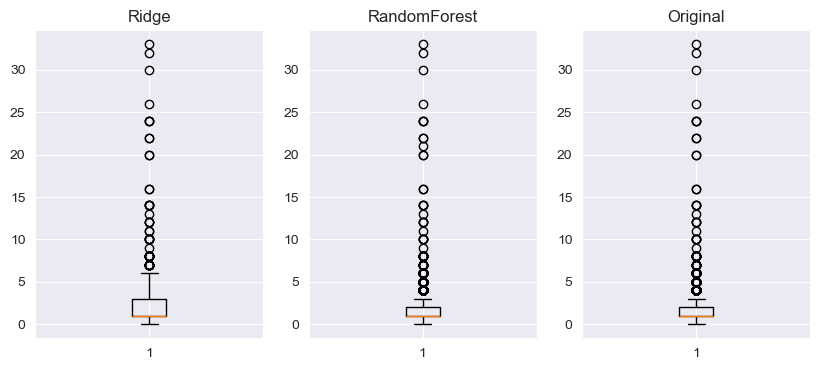

In [22]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.boxplot(df_iter_ridge["beds"].dropna())
plt.title("Ridge")

plt.subplot(1,3,2)
plt.boxplot(df_iter_rf["beds"].dropna())
plt.title("RandomForest")

plt.subplot(1,3,3)
plt.boxplot(df_cleaned["beds"].dropna())
plt.title("Original")

plt.show()


From the boxplots, RandomForest keeps a spread closer to the original data than Ridge does.

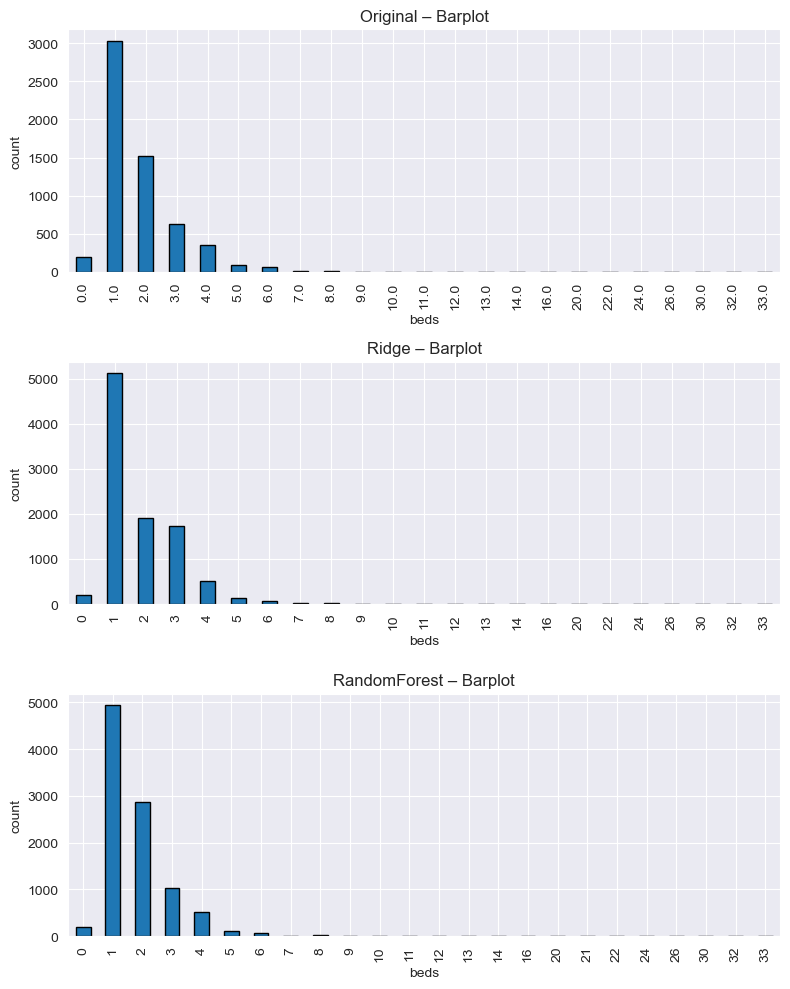

In [23]:
plt.figure(figsize=(8,10))

plt.subplot(3,1,1)
df_cleaned["beds"].value_counts().sort_index().plot(kind="bar", edgecolor="black")
plt.title("Original – Barplot")
plt.ylabel("count")

plt.subplot(3,1,2)
df_iter_ridge["beds"].value_counts().sort_index().plot(kind="bar", edgecolor="black")
plt.title("Ridge – Barplot")
plt.ylabel("count")

plt.subplot(3,1,3)
df_iter_rf["beds"].value_counts().sort_index().plot(kind="bar", edgecolor="black")
plt.title("RandomForest – Barplot")
plt.xlabel("beds")
plt.ylabel("count")

plt.tight_layout()
plt.show()


Again, RandomForest stays closer to the original shape than Ridge.

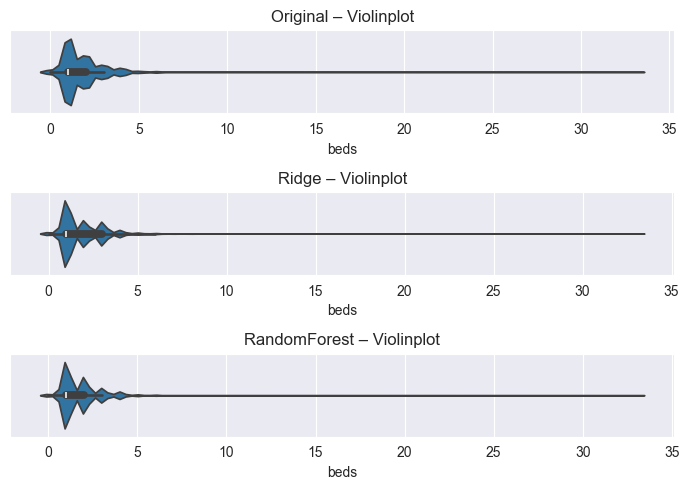

In [20]:

plt.figure(figsize=(7,5))

plt.subplot(3,1,1)
sns.violinplot(x=df_cleaned["beds"].dropna())
plt.title("Original – Violinplot")
plt.xlabel("beds")

# Ridge
plt.subplot(3,1,2)
sns.violinplot(x=df_iter_ridge["beds"])
plt.title("Ridge – Violinplot")
plt.xlabel("beds")

plt.subplot(3,1,3)
sns.violinplot(x=df_iter_rf["beds"])
plt.title("RandomForest – Violinplot")
plt.xlabel("beds")

plt.tight_layout()
plt.show()



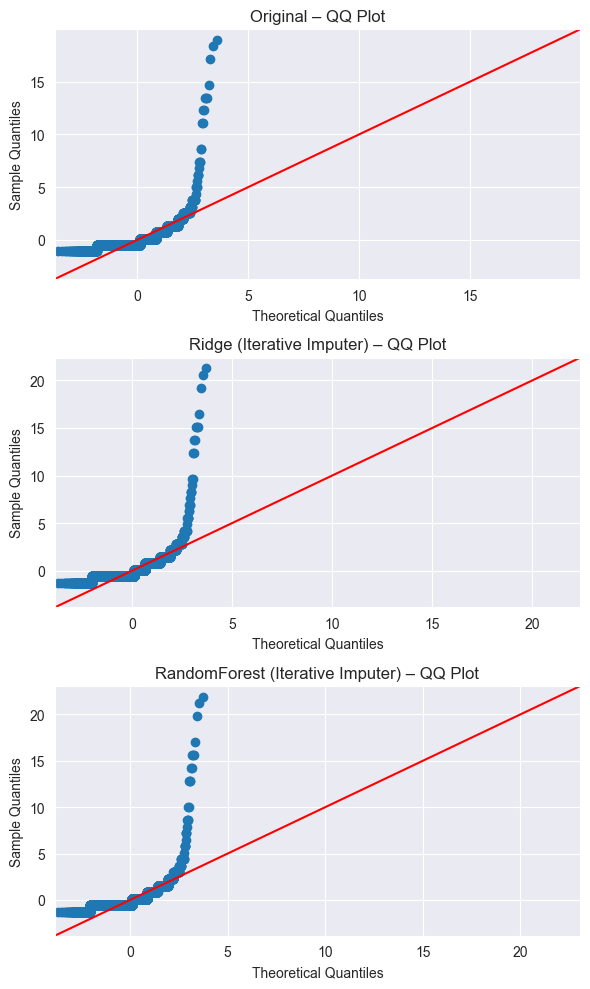

In [21]:
plt.figure(figsize=(6,10))

plt.subplot(3,1,1)
sm.qqplot(df_cleaned["beds"].dropna(), line="45", fit=True, ax=plt.gca())
plt.title("Original – QQ Plot")

plt.subplot(3,1,2)
sm.qqplot(df_iter_ridge["beds"], line="45", fit=True, ax=plt.gca())
plt.title("Ridge (Iterative Imputer) – QQ Plot")

plt.subplot(3,1,3)
sm.qqplot(df_iter_rf["beds"], line="45", fit=True, ax=plt.gca())
plt.title("RandomForest (Iterative Imputer) – QQ Plot")

plt.tight_layout()
plt.show()


Because beds is a variable with only a few possible values, violin plots and QQ plots don’t show any differences,they just make shapes that are hard to interpret.I will not use these visualizations or similar ones for next method

By other visualizations I can see that RandomForest did a better job than Ridge, I will use this model for future comparison.

## Model prediction input

Here I treat `beds` as the value to predict. I train a few models (Random Forest, Ridge, Lasso and XGBoost) to estimate beds from the other columns, then I compare them and keep the one whose filled values stay closest to the real distribution.

## Random Forest

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target = "beds"
feature_cols = (
    ["accommodates", "bedrooms", "price", "instant_bookable", "minimum_nights", "maximum_nights"] +
    [c for c in df_cleaned.columns if c.startswith("room_")] +
     [c for c in df_cleaned.columns if c.startswith("prop_")] +
    [c for c in df_cleaned.columns if c.startswith("bath_")] +
     [c for c in df_cleaned.columns if c.startswith("neighbourhood_")]

)

train_df = df_cleaned[df_cleaned[target].notna()].copy()
test_df  = df_cleaned[df_cleaned[target].isna()].copy()

X_all = df_cleaned[feature_cols].apply(pd.to_numeric, errors="coerce")
y_all = pd.to_numeric(df_cleaned["beds"], errors="coerce")

mask = y_all.notna()

X_tr, X_te, y_tr, y_te = train_test_split(X_all.loc[mask], y_all.loc[mask], test_size=0.3, random_state=1)

rf = RandomForestRegressor(n_estimators=180, max_depth=20, random_state=1)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)

print("MAE :", mean_absolute_error(y_te, y_pred))
print(f"RMSE: {(np.sqrt(mean_squared_error(y_te, y_pred))):.3f}")
print(f"R²:   {r2_score(y_te, y_pred):.3f}")


rf.fit(X_all.loc[mask], y_all.loc[mask])
pred_missing = rf.predict(X_all.loc[~mask])

df_rf_filled = df_cleaned.copy()
df_rf_filled.loc[~mask, "beds"] = np.rint(pred_missing)


MAE : 0.46706933433104075
RMSE: 0.805
R²:   0.720


In [25]:
from xgboost import XGBRegressor

target = "beds"

feature_cols = (
    ["accommodates", "bedrooms", "price", "instant_bookable", "minimum_nights", "maximum_nights"] +
    [c for c in df_cleaned.columns if c.startswith("room_")] +
     [c for c in df_cleaned.columns if c.startswith("prop_")] +
    [c for c in df_cleaned.columns if c.startswith("bath_")] +
     [c for c in df_cleaned.columns if c.startswith("neighbourhood_")]

)

X_num = df_cleaned[feature_cols].apply(pd.to_numeric, errors="coerce").astype("float64")
X_num = X_num.replace([np.inf, -np.inf], np.nan)

y_raw = pd.to_numeric(df_cleaned[target], errors="coerce")
mask_label_ok = y_raw.notna() & np.isfinite(y_raw)

X_all = X_num.loc[mask_label_ok].copy()
y_all = y_raw.loc[mask_label_ok].astype(float).copy()

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=1)

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=15,
    subsample=0.4,
    colsample_bytree=0.9,
    reg_alpha = 0.5,
    random_state=1,
)
xgb.fit(X_tr, y_tr)

y_pred = xgb.predict(X_te)

print("MAE :", mean_absolute_error(y_te, y_pred))
print(f"RMSE: {(np.sqrt(mean_squared_error(y_te, y_pred))):.3f}")
print(f"R²:   {r2_score(y_te, y_pred):.3f}")


xgb.fit(X_all, y_all)

df_xgb_filled = df_cleaned.copy()
miss_mask = ~mask_label_ok
X_miss = X_num.loc[miss_mask]

y_missing_pred = xgb.predict(X_miss)
y_missing_pred_rounded = np.clip(np.rint(y_missing_pred), 0, None).astype(int)

df_xgb_filled.loc[miss_mask, target] = y_missing_pred_rounded



MAE : 0.46779711290841175
RMSE: 0.774
R²:   0.742


## Ridge

In [26]:
target = "beds"

feature_cols = (
    ["accommodates", "bedrooms", "price", "instant_bookable", "minimum_nights", "maximum_nights"] +
    [c for c in df_cleaned.columns if c.startswith("room_")] +
     [c for c in df_cleaned.columns if c.startswith("prop_")] +
    [c for c in df_cleaned.columns if c.startswith("bath_")] +
     [c for c in df_cleaned.columns if c.startswith("neighbourhood_")]

)

X_num = df_cleaned[feature_cols].apply(pd.to_numeric, errors="coerce").astype("float64")
y_raw = pd.to_numeric(df_cleaned[target], errors="coerce")

mask = y_raw.notna() & np.isfinite(y_raw)
X_all = X_num.loc[mask].copy()
y_all = y_raw.loc[mask].astype(float).copy()

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=1)

feat_imp = SimpleImputer(strategy="median")
X_tr_imp = feat_imp.fit_transform(X_tr)
X_te_imp = feat_imp.transform(X_te)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_imp)
X_te_scaled = scaler.transform(X_te_imp)

ridge = Ridge(alpha=0.5)
ridge.fit(X_tr_scaled, y_tr)

y_pred = ridge.predict(X_te_scaled)
mae = mean_absolute_error(y_te, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_te, y_pred)))
r2 = r2_score(y_te, y_pred)

print("MAE :", mean_absolute_error(y_te, y_pred))
print(f"RMSE: {(np.sqrt(mean_squared_error(y_te, y_pred))):.3f}")
print(f"R²:   {r2_score(y_te, y_pred):.3f}")

X_all_imp = feat_imp.fit_transform(X_all)
X_all_scaled = scaler.fit_transform(X_all_imp)
ridge.fit(X_all_scaled, y_all)

coef_series = pd.Series(ridge.coef_, index=X_all.columns).sort_values(key=np.abs, ascending=False)
nonzero = int((coef_series != 0).sum())
print(f"\nNon-zero coefficients: {nonzero}/{len(coef_series)}")
print("\ncoefficients:")
print(coef_series)

df_ridge_filled = df_cleaned.copy()
mask_missing = ~mask

X_miss = X_num.loc[mask_missing].copy()

X_miss_imp = feat_imp.transform(X_miss)
X_miss_scaled = scaler.transform(X_miss_imp)

y_missing_pred = ridge.predict(X_miss_scaled)

y_missing_pred_rounded = np.clip(np.rint(y_missing_pred), 0, None).astype(int)
df_ridge_filled.loc[mask_missing, target] = y_missing_pred_rounded

MAE : 0.5940395088113564
RMSE: 0.900
R²:   0.650

Non-zero coefficients: 34/34

coefficients:
accommodates                              0.973114
bedrooms                                  0.480624
prop_boat                                 0.150487
room_Shared room                          0.089483
prop_entire home                         -0.069814
bath_other                                0.054276
bath_1.5 shared_bath                      0.048652
room_Entire home/apt                     -0.042587
bath_2 bath                              -0.039109
prop_entire rental unit                  -0.037432
prop_room in hotel                        0.036307
prop_entire condo                        -0.033230
prop_other                                0.032290
room_Private room                         0.030027
prop_houseboat                            0.029313
prop_private room in rental unit          0.027675
prop_private room in bed and breakfast    0.024477
prop_room in boutique hotel            

## Lasso

In [27]:
from sklearn.linear_model import Lasso


target = "beds"

feature_cols = (
    ["accommodates", "bedrooms", "price", "instant_bookable", "minimum_nights", "maximum_nights"] +
    [c for c in df_cleaned.columns if c.startswith("room_")] +
     [c for c in df_cleaned.columns if c.startswith("prop_")] +
    [c for c in df_cleaned.columns if c.startswith("bath_")] +
     [c for c in df_cleaned.columns if c.startswith("neighbourhood_")]

)

X_num = df_cleaned[feature_cols].apply(pd.to_numeric, errors="coerce").astype("float64")
y_raw = pd.to_numeric(df_cleaned[target], errors="coerce")

mask_known = y_raw.notna() & np.isfinite(y_raw)
X_all = X_num.loc[mask_known].copy()
y_all = y_raw.loc[mask_known].astype(float).copy()

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=1)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

lasso = Lasso(alpha=0.01, max_iter=2000)
lasso.fit(X_tr_scaled, y_tr)

y_pred = lasso.predict(X_te_scaled)
mae = mean_absolute_error(y_te, y_pred)
rmse = mean_squared_error(y_te, y_pred)
r2 = r2_score(y_te, y_pred)
print("MAE :", mean_absolute_error(y_te, y_pred))
print(f"RMSE: {(np.sqrt(mean_squared_error(y_te, y_pred))):.3f}")
print(f"R²:   {r2_score(y_te, y_pred):.3f}")

X_all_scaled = scaler.fit_transform(X_all)
lasso.fit(X_all_scaled, y_all)

coef_series = pd.Series(lasso.coef_, index=X_all.columns).sort_values(key=np.abs, ascending=False)
nonzero = int((coef_series != 0).sum())
print(f"\nNon-zero coefficients: {nonzero}/{len(coef_series)}")
print("\ncoefficients:")
print(coef_series)


df_lasso_filled = df_cleaned.copy()

mask_missing = ~mask_known
X_miss = X_num.loc[mask_missing].copy()

X_miss_scaled = scaler.transform(X_miss)
y_missing_pred = lasso.predict(X_miss_scaled)

y_missing_pred_rounded = np.clip(np.rint(y_missing_pred), 0, None).astype(int)
df_lasso_filled.loc[mask_missing, target] = y_missing_pred_rounded


MAE : 0.5834887466047379
RMSE: 0.895
R²:   0.654

Non-zero coefficients: 19/34

coefficients:
accommodates                              0.973584
bedrooms                                  0.454814
prop_boat                                 0.149518
room_Entire home/apt                     -0.140604
room_Shared room                          0.076685
bath_other                                0.051088
prop_entire home                         -0.040668
bath_1.5 shared_bath                      0.038351
prop_houseboat                            0.027612
bath_2 bath                              -0.021630
instant_bookable                          0.012331
maximum_nights                            0.011058
prop_room in hotel                        0.008537
prop_entire condo                        -0.006928
prop_other                                0.006662
price                                     0.005213
prop_entire rental unit                  -0.004646
bath_1 shared_bath                     

/var/folders/kf/d6_rnqqd78b0c445btm4gpgc0000gn/T/ipykernel_3440/1107895657.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Original",  "RF", "XGB","Ridge", "Lasso"])


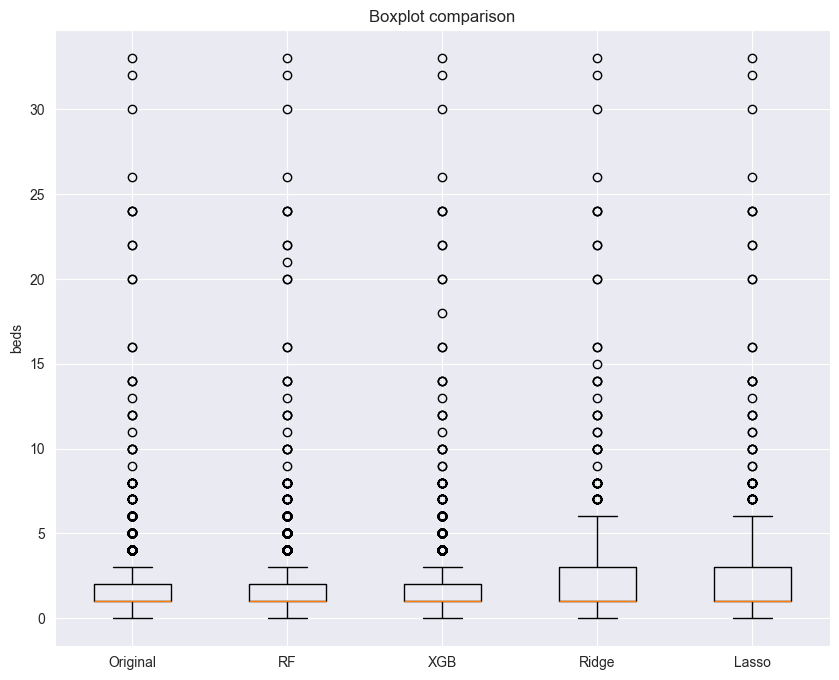

In [30]:
plt.figure(figsize=(10,8))
data = [
    df_cleaned["beds"].dropna(),
    df_rf_filled["beds"].dropna(),
    df_xgb_filled["beds"].dropna(),
    df_ridge_filled["beds"].dropna(),
    df_lasso_filled["beds"].dropna()
]

plt.boxplot(data, labels=["Original",  "RF", "XGB","Ridge", "Lasso"])
plt.title("Boxplot comparison")
plt.ylabel("beds")
plt.show()

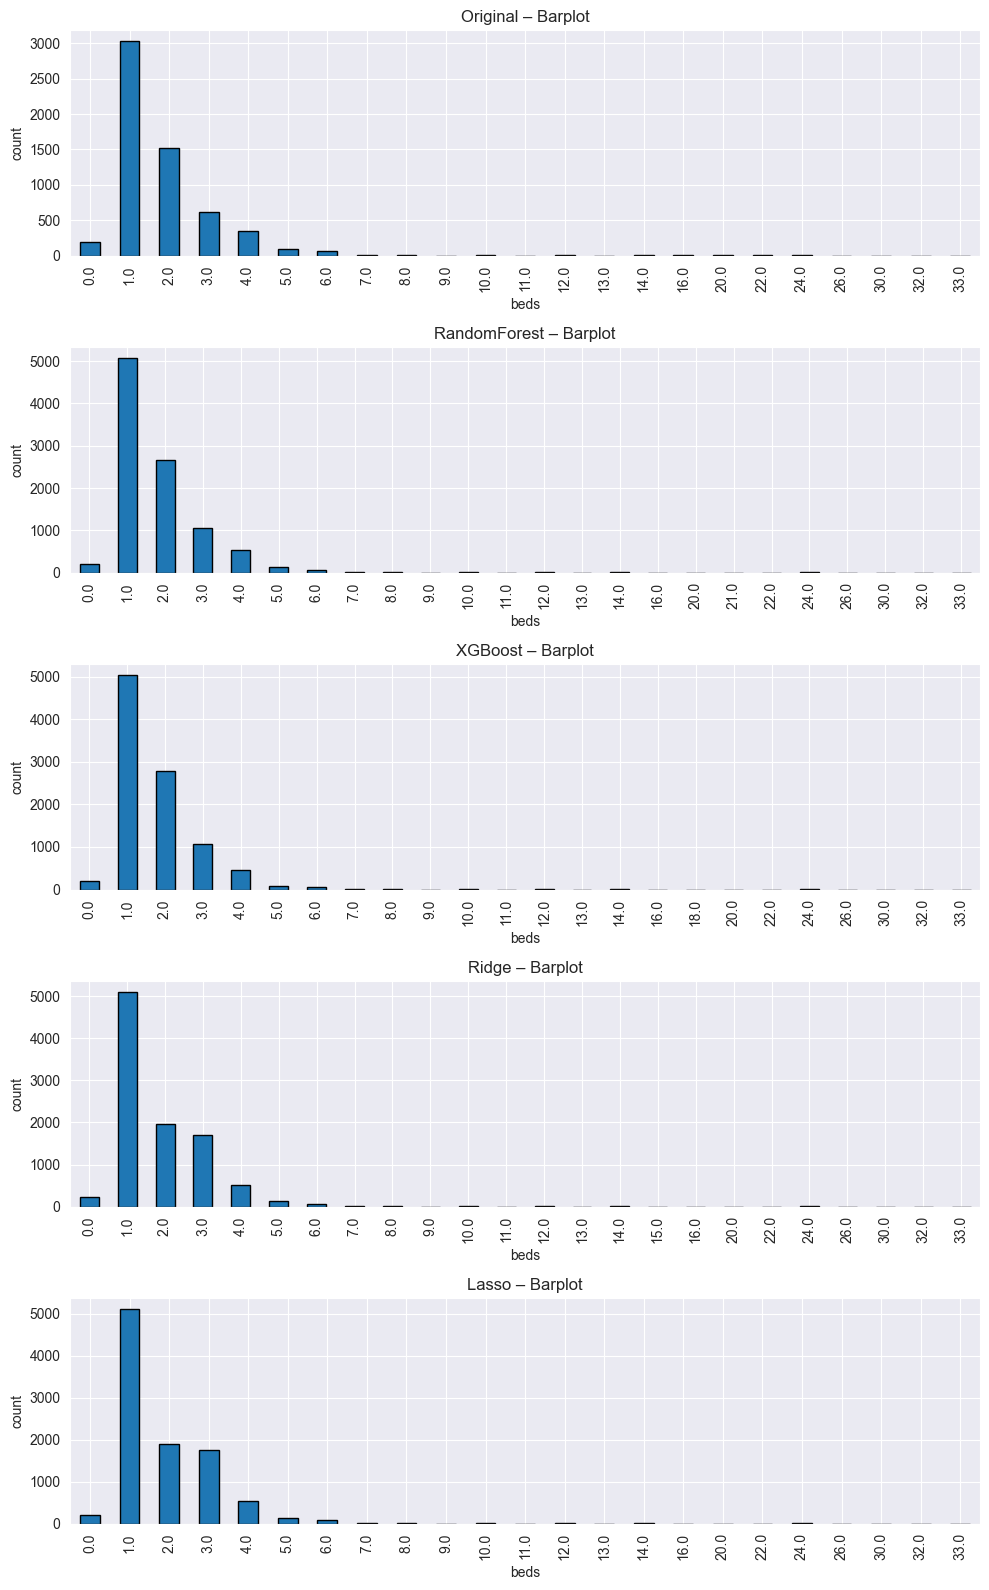

In [31]:
plt.figure(figsize=(10,16))

datasets = {
    "Original": df_cleaned,
    "RandomForest": df_rf_filled,
    "XGBoost": df_xgb_filled,
    "Ridge": df_ridge_filled,
    "Lasso": df_lasso_filled
}

for i, (name, df_temp) in enumerate(datasets.items(), start=1):
    plt.subplot(len(datasets), 1, i)
    df_temp["beds"].value_counts().sort_index().plot(kind="bar",edgecolor="black")
    plt.title(f"{name} – Barplot")
    plt.ylabel("count")

plt.tight_layout()
plt.show()


XGBoost is the best imputation model because it has the lowest error ( the best MAE/RMSE scores) and its filled valuesto keep the original distribution almost unchanged, which I can clearly see on the barplots and boxplots. Random forest is the second-best choice.

### Comparisson of different input methods

/var/folders/kf/d6_rnqqd78b0c445btm4gpgc0000gn/T/ipykernel_42230/40424925.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Original","Median", "Iter-RF","XGB"])


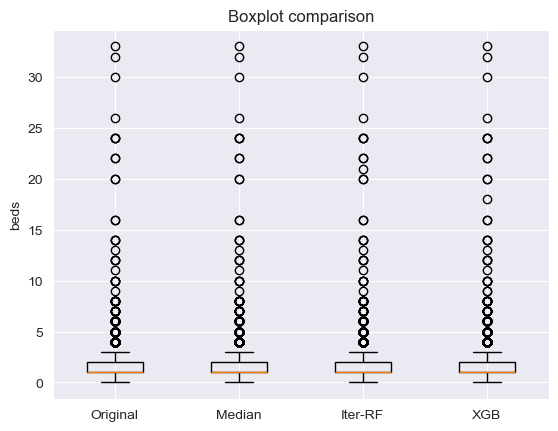

In [28]:

data = [
    df_cleaned["beds"].dropna(),
    df_median["beds"].dropna(),
    df_iter_rf["beds"].dropna(),
    df_xgb_filled["beds"].dropna(),

]
plt.boxplot(data, labels=["Original","Median", "Iter-RF","XGB"])
plt.title("Boxplot comparison")
plt.ylabel("beds")
plt.show()


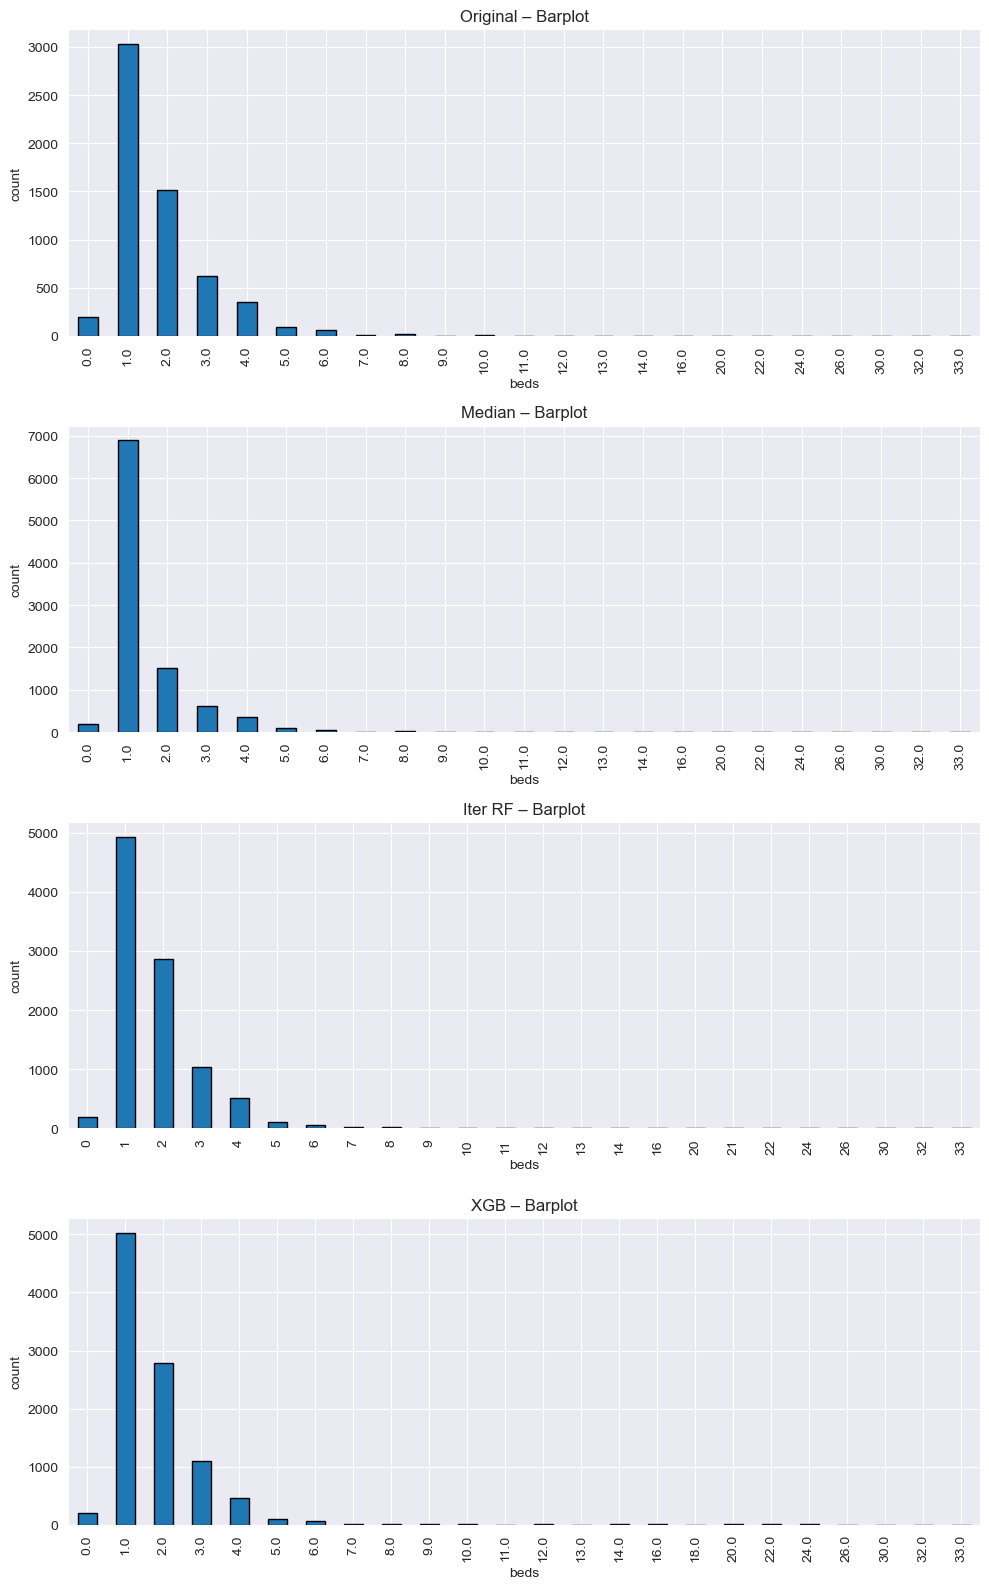

In [29]:
plt.figure(figsize=(10,16))

datasets = {
    "Original": df_cleaned,
    "Median": df_median,
    "Iter RF": df_iter_rf,
    "XGB": df_xgb_filled,
}

for i, (name, df_temp) in enumerate(datasets.items(), start=1):
    plt.subplot(len(datasets), 1, i)
    df_temp["beds"].value_counts().sort_index().plot(kind="bar",edgecolor="black")
    plt.title(f"{name} – Barplot")
    plt.ylabel("count")

plt.tight_layout()
plt.show()

 Median imputation is not suitable here, because it collapses most missing rows into just 1–2 beds and destroys the original distribution.Iterative Imputer and XGBoost both preserve the true shape much better, but XGBoost is slightly closer to the original. After limiting the y-axis with plt.ylim(0, 200), the differences become clearer, XGBoost keeps the tail and the peaks almost identical to the real data. It also shows the best accuracy metrics, so I chose XGBoost as the final approach

In [30]:
df_filled = df_cleaned.copy()
df_filled["beds"] = df_cleaned["beds"].fillna(df_iter_rf["beds"])

print("NaN after fill:", df_filled["beds"].isna().sum())

NaN after fill: 0


I have full dataset with no missing values, for now i will keep room_ bath_ prop_ neighbourhood_ columns for future visualizations as I explained before.

## Find and remove anomalies

In [45]:
print(df_filled.describe())

                 id     latitude    longitude         price  accommodates     bedrooms         beds  minimum_nights  maximum_nights  availability_365  estimated_occupancy_l365d  \
count  9.775000e+03  9775.000000  9775.000000   9775.000000   9775.000000  9775.000000  9775.000000     9775.000000     9775.000000       9775.000000                9775.000000   
mean   5.288263e+17    52.366611     4.889319    210.478705      2.953862     1.558056     1.765320        4.088491      294.606240         87.084092                  51.410844   
std    5.198223e+17     0.017071     0.034903    683.487039      1.311367     0.895776     1.394897       17.186624      395.277005        114.196387                  77.964239   
min    2.818000e+03    52.290276     4.755870     10.000000      1.000000     0.000000     0.000000        1.000000        1.000000          0.000000                   0.000000   
25%    2.421138e+07    52.355730     4.864625    120.000000      2.000000     1.000000     1.000000 

For the next steps I noticed that my dataset have some placeholders/anomalies such as minimum and maximum night 1001-1125 , price 50000, beds 33 etc.
I need to clean that, otherwise it could affect model results

### Boxplots

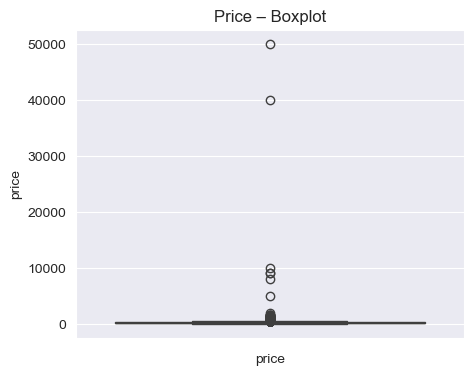

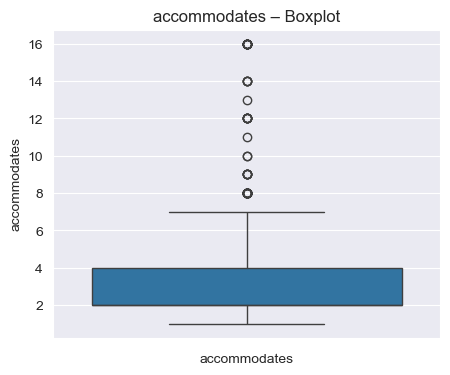

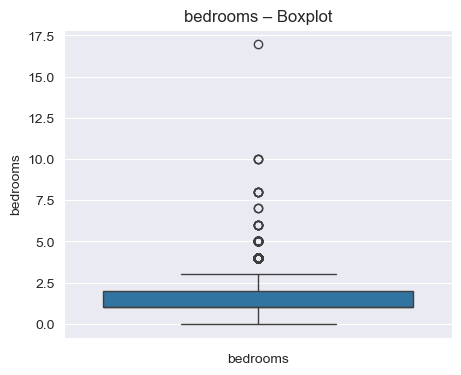

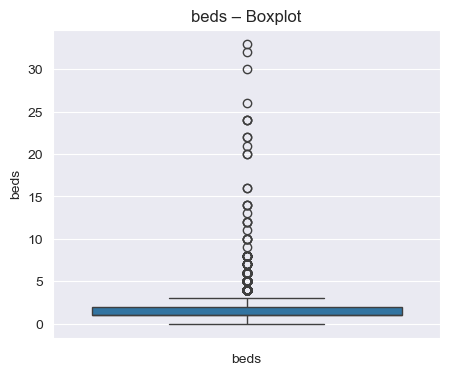

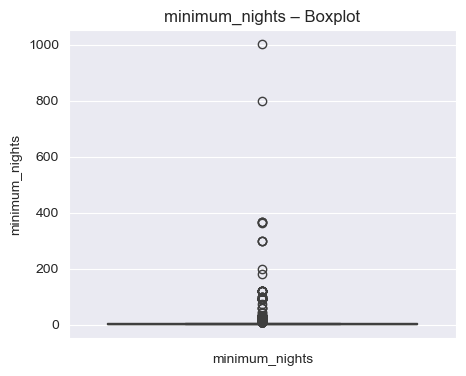

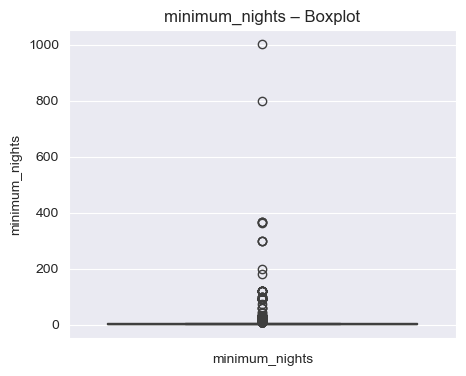

In [31]:
plt.figure(figsize=(5,4))


sns.boxplot(y=df_filled["price"])
plt.title("Price – Boxplot")
plt.xlabel("price")
#plt.ylim(0, 6000)
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(y=df_filled["accommodates"])
plt.title("accommodates – Boxplot")
plt.xlabel("accommodates")
#plt.ylim(0, 6000)
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(y=df_filled["bedrooms"])
plt.title("bedrooms – Boxplot")
plt.xlabel("bedrooms")
#plt.ylim(0, 6000)
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(y=df_filled["beds"])
plt.title("beds – Boxplot")
plt.xlabel("beds")
#plt.ylim(0, 6000)
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(y=df_filled["minimum_nights"])
plt.title("minimum_nights – Boxplot")
plt.xlabel("minimum_nights")
#plt.ylim(0, 6000)
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(y=df_filled["minimum_nights"])
plt.title("minimum_nights – Boxplot")
plt.xlabel("minimum_nights")
#plt.ylim(0, 6000)
plt.show()


Boxplots show numerical features contain a small number of extreme values. Most data points are concentrated close to the median with only a few far outside. These extreme points mostly can be interpreted as large houses, big apartments or rare listings, rather than errors. Instead of removing them , I keep them in the dataset for now. For the price I will use log-transformation, this compresses large values and spreads small ones, rf and boosting dont need it, but linear models will have better accuracy with this approach

Lets also see boxplot of logged price to compare with original

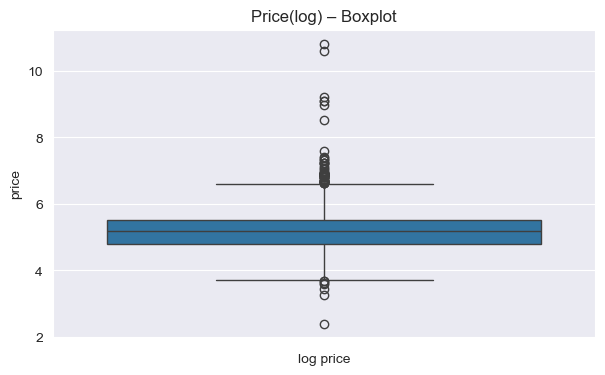

In [32]:
plt.figure(figsize=(7,4))
sns.boxplot(y=np.log1p(df_filled["price"]))
plt.title("Price(log) – Boxplot")
plt.xlabel("log price")
plt.show()


### Z-score

In [33]:
from scipy.stats import zscore
for col in ["price","accommodates","beds","bedrooms", "minimum_nights", "maximum_nights"]:
    z = np.abs(zscore(df_filled[col]))
    print(col, (z > 3).sum(), "extreme values")

price 7 extreme values
accommodates 102 extreme values
beds 59 extreme values
bedrooms 54 extreme values
minimum_nights 41 extreme values
maximum_nights 0 extreme values


Using a Z-score threshold of 3(99.7% of values in a normal distribution), the dataset have a very small fraction of the whole dataset, and these extremes are realistic rather than incorrect records. Removing them would reduce data diversity, so it is better to keep them

Only features left for changing is minimun and maximum nights as any values above 365 mostly placeholders or errors, instead of removing them I just transform it

In [34]:
df_filled.loc[df_filled["maximum_nights"] > 365, "maximum_nights"] = 365
df_filled.loc[df_filled["minimum_nights"] > 365, "minimum_nights"] = 365
df_filled["log_price"] = np.log1p(df_filled["price"])

In [35]:
df_filled.describe()

,id,latitude,longitude,price,accommodates,bedrooms,beds,minimum_nights,maximum_nights,availability_365,estimated_occupancy_l365d,instant_bookable,room_Entire home/apt,room_Hotel room,room_Private room,room_Shared room,region_area_m2_left,dist_to_region_centroid_m,dist_to_city_center_m,region_area_m2_right,prop_boat,prop_entire condo,prop_entire home,prop_entire loft,prop_entire rental unit,prop_entire serviced apartment,prop_entire townhouse,prop_houseboat,prop_other,prop_private room in bed and breakfast,prop_private room in condo,prop_private room in home,prop_private room in rental unit,prop_room in boutique hotel,prop_room in hotel,bath_1 bath,bath_1 private_bath,bath_1 shared_bath,bath_1.5 bath,bath_1.5 shared_bath,bath_2 bath,bath_2.5 bath,bath_3 bath,bath_other,log_price
count,9.775000e+03,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.0,9775.000000,9775.000000,9775.000000,9775.000000,9.775000e+03,9775.000000,9775.000000,9.775000e+03,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000
mean,5.288263e+17,52.366611,4.889319,210.478705,2.953862,1.558056,1.787826,3.978926,166.730844,87.084092,51.410844,0.150077,0.827621,0.004092,0.165524,0.002762,5.555252e+06,870.355063,2580.941492,5.555252e+06,0.011662,0.175857,0.105985,0.024859,0.440921,0.010946,0.022813,0.018619,0.061176,0.029258,0.015038,0.013299,0.033862,0.010332,0.025371,0.520307,0.086240,0.030895,0.245217,0.013197,0.056675,0.020358,0.010537,0.016573,5.125481
std,5.198223e+17,0.017071,0.034903,683.487039,1.311367,0.895776,1.410952,12.471099,167.385081,114.196387,77.964239,0.357165,0.377728,0.063842,0.371672,0.052486,5.824710e+06,560.614855,1611.789236,5.824710e+06,0.107367,0.380718,0.307834,0.155704,0.496523,0.104056,0.149316,0.135182,0.239666,0.168538,0.121712,0.114559,0.180883,0.101127,0.157257,0.499613,0.280733,0.173042,0.430238,0.114123,0.231233,0.141229,0.102113,0.127671,0.590840
min,2.818000e+03,52.290276,4.755870,10.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,2.193047e+06,13.908799,73.261294,2.193047e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.397895
25%,2.421138e+07,52.355730,4.864625,120.000000,2.000000,1.000000,1.000000,2.000000,21.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,3.327156e+06,533.045592,1468.179809,3.327156e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.795791
50%,6.431860e+17,52.365507,4.887260,180.000000,2.000000,1.000000,1.000000,3.000000,30.000000,25.000000,20.000000,0.0,1.000000,0.000000,0.000000,0.000000,4.388390e+06,789.124746,2274.645156,4.388390e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.198497
75%,1.018075e+18,52.376390,4.908300,250.000000,4.000000,2.000000,2.000000,4.000000,365.000000,154.500000,55.000000,0.0,1.000000,0.000000,0.000000,0.000000,5.403480e+06,1062.303156,3182.410318,5.403480e+06,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.525453
max,1.367370e+18,52.425120,5.026669,50000.000000,16.000000,17.000000,33.000000,365.000000,365.000

After I cleaned my dataset, for the next step I want to create new features using combination of already existing ones and amnesties

## Feature engineering

At first, I want to create new features of already existing listings properties that could be usefull for model prediction.

In [36]:
df_filled["beds_per_bedroom"] = np.where((df_filled["bedrooms"] > 0) & (df_filled["beds"] > 0),df_filled["beds"] / df_filled["bedrooms"],0)
df_filled["occupancy_ratio"] = np.where(df_filled["beds"] > 0,df_filled["accommodates"] / df_filled["beds"],0)
df_filled["stay_flexibility"] = df_filled["maximum_nights"] / (df_filled["minimum_nights"] )
df_filled["availability_ratio"] = df_filled["availability_365"] / 365

In [37]:
df_filled.describe()

,id,latitude,longitude,price,accommodates,bedrooms,beds,minimum_nights,maximum_nights,availability_365,estimated_occupancy_l365d,instant_bookable,room_Entire home/apt,room_Hotel room,room_Private room,room_Shared room,region_area_m2_left,dist_to_region_centroid_m,dist_to_city_center_m,region_area_m2_right,prop_boat,prop_entire condo,prop_entire home,prop_entire loft,prop_entire rental unit,prop_entire serviced apartment,prop_entire townhouse,prop_houseboat,prop_other,prop_private room in bed and breakfast,prop_private room in condo,prop_private room in home,prop_private room in rental unit,prop_room in boutique hotel,prop_room in hotel,bath_1 bath,bath_1 private_bath,bath_1 shared_bath,bath_1.5 bath,bath_1.5 shared_bath,bath_2 bath,bath_2.5 bath,bath_3 bath,bath_other,log_price,beds_per_bedroom,occupancy_ratio,stay_flexibility,availability_ratio
count,9.775000e+03,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.0,9775.000000,9775.000000,9775.000000,9775.000000,9.775000e+03,9775.000000,9775.000000,9.775000e+03,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000,9775.000000
mean,5.288263e+17,52.366611,4.889319,210.478705,2.953862,1.558056,1.787826,3.978926,166.730844,87.084092,51.410844,0.150077,0.827621,0.004092,0.165524,0.002762,5.555252e+06,870.355063,2580.941492,5.555252e+06,0.011662,0.175857,0.105985,0.024859,0.440921,0.010946,0.022813,0.018619,0.061176,0.029258,0.015038,0.013299,0.033862,0.010332,0.025371,0.520307,0.086240,0.030895,0.245217,0.013197,0.056675,0.020358,0.010537,0.016573,5.125481,1.128331,1.783646,87.908336,0.238587
std,5.198223e+17,0.017071,0.034903,683.487039,1.311367,0.895776,1.410952,12.471099,167.385081,114.196387,77.964239,0.357165,0.377728,0.063842,0.371672,0.052486,5.824710e+06,560.614855,1611.789236,5.824710e+06,0.107367,0.380718,0.307834,0.155704,0.496523,0.104056,0.149316,0.135182,0.239666,0.168538,0.121712,0.114559,0.180883,0.101127,0.157257,0.499613,0.280733,0.173042,0.430238,0.114123,0.231233,0.141229,0.102113,0.127671,0.590840,0.579254,0.550888,118.235821,0.312867
min,2.818000e+03,52.290276,4.755870,10.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,2.193047e+06,13.908799,73.261294,2.193047e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.397895,0.000000,0.000000,1.000000,0.000000
25%,2.421138e+07,52.355730,4.864625,120.000000,2.000000,1.000000,1.000000,2.000000,21.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,3.327156e+06,533.045592,1468.179809,3.327156e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.795791,1.000000,1.500000,6.000000,0.000000
50%,6.431860e+17,52.365507,4.887260,180.000000,2.000000,1.000000,1.000000,3.000000,30.000000,25.000000,20.000000,0.0,1.000000,0.000000,0.000000,0.000000,4.388390e+06,789.124746,2274.645156,4.388390e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.198497,1.000000,2.000000,15.000000,0.068493
75%,1.018075e+18,52.376390,4.908300,250.000000,4.000000,2.000000,2.000000,4.000000,365.000000,154.500000,55.000000,0.0,1.000000,0.000000,0.000000,0.000000,5.403480e+06,1062.303156,3182.410318,5.403480e+06,0.000000,0.000000,0.0

## Amenities preparation

### Top words overview

In [38]:
from collections import Counter
from itertools import chain

words = chain.from_iterable(df_filled["amenities"].dropna().str.split(",\n"))
common = Counter(map(str.strip, words)).most_common(50)
print(common)


[('["Smoke alarm", "Washer", "Wifi", "TV", "Kitchen"]', 16), ('["Refrigerator", "Stove", "Smoke alarm", "Hot water", "Wifi", "First aid kit", "Luggage dropoff allowed", "Microwave", "Bed linens", "Fire extinguisher", "Elevator", "Cooking basics", "Hair dryer", "Kitchen", "Oven"]', 12), ('["Heating", "Hot water", "TV", "Wifi", "Room-darkening shades", "Luggage dropoff allowed", "Essentials", "Shower gel", "Bed linens", "Hair dryer", "Conditioner", "Shampoo", "Air conditioning"]', 11), ('["Dedicated workspace", "Washer", "Wifi", "TV", "Kitchen"]', 8), ('["Body soap", "Exterior security cameras on property", "Paid parking off premises", "Conditioner", "Coffee maker", "Shampoo", "Hangers", "Mini fridge", "Heating", "Hot water kettle", "Luggage dropoff allowed", "Bed linens", "Safe", "Fire extinguisher", "Breakfast", "Paid dryer \\u2013 In building", "Shared patio or balcony", "Hot water", "Wifi", "Waterfront", "Host greets you", "Shower gel", "Portable fans", "Iron", "Hair dryer", "Refrige

### Cleaning

In [39]:
df_clean = df_filled.copy()

def clean_amenities(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[\[\]\{\}\(\)\"']", " ", text)
    text = re.sub(r"[^a-zA-Zа-яА-Я0-9,.\s\-_/+]", " ", text)
    text = re.sub(r"\d+\s*(mbps|gb|m2|stars?|°c|°f|hz)?", " ", text)
    text = re.sub(r"[-_/+]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_clean["amenities_cleaned"] = df_clean["amenities"].apply(clean_amenities)

def split_amenities_str(s: str):
    parts = [p.strip() for p in s.split(",")]
    parts = [p.strip(' "\'') for p in parts if p.strip(' "\'')]
    return parts

df_clean["amenities_cleaned"] = df_clean["amenities_cleaned"].apply(split_amenities_str)
print(df_clean["amenities_cleaned"])


0        [ph neutral and dermatologically tested body s...
1        [heating split type ductless system, private e...
2        [refrigerator, hangers, smoke alarm, cleaning ...
3        [refrigerator, hangers, smoke alarm, private e...
4        [private entrance, paid parking off premises, ...
                               ...                        
10070    [hangers, heating, hot water, tv, wifi, indoor...
10071    [private entrance, coffee maker espresso machi...
10072    [smoke alarm, washer, wifi, tv, outdoor dining...
10073    [smoke alarm, mini fridge, hot water, wifi, be...
10074    [radiant heating, children s playroom, clothin...
Name: amenities_cleaned, Length: 9775, dtype: object


### Normalizing

In [40]:
import re

for var in ["core_set", "alias_map", "modifier_list", "modifier_set", "ignore_set"]:
    if var in globals(): del globals()[var]

core_set = {
    "wifi","kitchen","washer","dryer","tv","parking","heating","air_conditioning",
    "refrigerator","microwave","oven","dishwasher","hair_dryer","iron","smoke_alarm",
    "balcony","terrace","garden","gym","pool","garage","bbq_grill","blender","bathtub",
    "backyard","coffee_maker","speaker","stove","xbox","sound_system","bread_maker","bidet",
    "baby_bath","safety_gates","baby_monitor","changing_table","chromecast","board_games",
    "bikes","ev_charger","view","streaming_services","beach_access","bath_toiletries",
    "high_chair","climbing_wall","cleaning_service","clothing_storage","crib","dining_table",
    "exercise_equipment","game_console","shower","elevator","co_alarm","fireplace","hot_tub",
    "sauna","lake","resort","boat_slip","kayak","piano","ping_pong_table","dining_area",
    "furniture","record_player","rice_maker","workspace","kettle","toaster","trash_compactor",
    "first_aid_kit","fire_extinguisher","lockbox","safe","smoking_allowed","bedroom_lock",
    "blackout_shades","pets_allowed","playground","home_theater","noise_monitors","heater",
    "fan","kitchen_utensils","essentials","fire_pit","hammock","mosquito_net", "waterfront","ski_in_ski_out", "bowling_alley","batting_cage","hockey_rink","skate_ramp","mini_golf","sun_loungers", "hammock", "books","sun_loungers","single_level_home", "housekeeping"
}

alias_map = {
    "wifi": ["wi fi","wi-fi","wireless internet","internet","ethernet connection"],
    "air_conditioning": ["ac","aircon","a/c","air conditioning"],
    "refrigerator": ["fridge","mini fridge"],
    "tv": ["smart tv","hdtv"],
    "parking": ["driveway"],

    "sound_system": [
        "soundbar","soundtouch","bluetooth sound system",
        "sound system with bluetooth and aux","sound system with aux",
        "cd player radio","dvd player"
    ],

    "board_games": ["arcade games"],
    "coffee_maker": ["espresso machine","french press","drip coffee maker","nespresso","keurig","pour over coffee","coffee"],
    "beach_access": ["beachfront"],
    "backyard": ["backyard fully fenced","backyard not fully fenced"],
    "bath_toiletries": ["body soap","shampoo","conditioner","shower gel","bodywash","douchegel"],
    "streaming_services": ["netflix","amazon prime","amazon prime video","disney","disney+","hbo max","spotify","premium cable","standard cable","roku","hulu","prime video"],
    "clothing_storage": ["closet","wardrobe","dresser","clothing storage closet","clothing storage dresser","clothing storage wardrobe","clothing storage walk in closet","hangers"],
    "exercise_equipment": ["exercise equipment","exercise equipment treadmill","exercise equipment elliptical","exercise equipment rowing","exercise equipment stationary bike","exercise equipment workout bench","exercise equipment yoga mat","treadmill","stationary bike","workout bench","yoga mat","rowing machine"],
    "fan": ["fans"],
    "workspace": ["dedicated workspace"],
    "kitchen_utensils": ["kitchenette","cooking basics","dishes and silverware","dining area","wine glasses","baking sheet","barbecue utensils"],
    "kettle": ["hot water kettle"],
    "home_theater": ["movie theater"],
    "washer": ["laundromat nearby"],

    "co_alarm": ["carbon monoxide alarm","co alarm","co detector"],
    "ping_pong_table": ["table tennis"],
    "boat_slip": ["boat dock slip"],
    "record_player": ["record player","turntable"],
    "bedroom_lock": ["lock on bedroom door","smart lock"],
    "noise_monitors": ["noise decibel monitors on property"],
    "blackout_shades": ["room darkening shades"],
    "books" : ["reading material"],
    "game_console": ["game console", "nintendo wii", "wii u", "playstation", "xbox", "xbox one","x one","x-one"],
    "sun_loungers": ["sun beds", "deck chairs"],
    "single_level_home": ["single storey home", "single story home"],
    "housekeeping" : ["housekeeping available"]
}

modifier_list = [
    "private","ensuite","shared","free","paid","heated","fast","slow","in unit","in building","on premises","off premises","canal","city_skyline","garden","beach","bay","access","portable","ceiling","gas","electric"
]

modifier_set = set(modifier_list)

ignore_set = {
    "host greets you","long term stays allowed","self check-in","cleaning available during stay",
    "bed linens","extra pillows and blankets","luggage dropoff allowed","keypad",
    "day a week available at extra cost","days a week available at extra cost",
    "every day available at extra cost","every day included with your stay",
    "monday to friday available at extra cost","friday available at extra cost",
    "saturday available at extra cost","thursday available at extra cost",
    "thursday to friday available at extra cost","sunday to saturday available at extra cost",
    "housekeeping included with your stay", "lock on bedroom door", "smart lock", "all in one hair", "babysitter recommendations", "bed linens"

}
token_ignore_set = {
    "bose","sonos","jbl","apple","amazon","echo","bang","olufsen","beoplay","denon","marantz","kef","onkyo","philips",
    "samsung","sennheiser","logitech","cambridge","bluesound","bluenode","aiwa","argon","grundig","ruark","marshall",
    "klipsch","mi","google","nest","homepods","homepod","alexa","heos","teufel","tannoy","rotel","devon","ibiza","hg",
    "sony","bowers","wilkins","harman","kardon","quad","diapason","focal","aurel","mini","studio","yamaha","smeg","siemens","atag","hp","kneipp","always organic", "blendax", "yamaha"

    "receiver","cinema","connect","pair","ps","nintendo","switch","wii",

    "rituals","aesop","andrelon","nivea","palmolive","sanex","care","dove","blendax","fa","niveau",
    "ah","albert","heijn","huismerk","brand","brands","vintage","unknown","name","edition","series","signature",
    "collection","line","original","different","various","assorted","miscellaneous","merk","model",

    "with","and","or","the","of","for","to","by","included","available","provided","always","upon","request",
    "ps", "years old"
    "day","week","weeks","cost","extra","stay","listing","per","night","u","fam","fpm","open","hours","specific",

    "wood_burning", "saltwater","olympic_sized", "you get", "years old"
    #"premium"
}



def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"[-_/]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s

def words_pattern(phrase: str) -> str:

    parts = normalize_text(phrase).split()
    return r"\b" + r"[ _-]+".join(map(re.escape, parts)) + r"\b"

def strip_ignored_tokens(phrase: str) -> str:
    t = normalize_text(phrase)
    for m in [m for m in modifier_list if " " in m]:
        t = t.replace(m, m.replace(" ", "_"))
    tokens = t.split()
    kept = [tok for tok in tokens if tok not in token_ignore_set]
    t = " ".join(kept)
    t = t.replace("_", " ")
    return t

core_patterns = {core: re.compile(words_pattern(core.replace("_"," "))) for core in core_set}
alias_patterns = {}
modifier_patterns = {}

for core, variants in alias_map.items():
    pats = [re.compile(words_pattern(v)) for v in variants]
    alias_patterns[core] = pats

for m in modifier_list:
    modifier_patterns[m] = re.compile(words_pattern(m))

def find_cores(phrase: str) -> list[str]:

    t = strip_ignored_tokens(phrase)
    found = set()
    for core, pat in core_patterns.items():
        if pat.search(t):
            found.add(core)
    for core, pats in alias_patterns.items():
        if any(p.search(t) for p in pats):
            found.add(core)
    return list(found)

def find_modifier(phrase: str) -> str | None:
    t = strip_ignored_tokens(phrase)
    for m, pat in modifier_patterns.items():
        if pat.search(t):
            return m
    return None

def extract_features(tokens: list[str]) -> list[str]:

    feats = set()
    for raw in tokens:
        phrase_norm = normalize_text(raw)
        if phrase_norm in ignore_set:
            continue
        cores = find_cores(raw)
        if not cores:
            continue
        mod = find_modifier(raw)
        mod_token = mod.replace(" ", "_") if mod else None
        for core in cores:
            feats.add(f"amenity_{core}__{mod_token}" if mod_token else f"amenity_{core}")
    return sorted(feats)



### TfidfVectorizer Preparing

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer


for col in ["amenity_feats", "amenity_str"]:
    if col in df_clean.columns:
        df_clean.drop(columns=[col], inplace=True)

df_clean["amenity_feats"] = df_clean["amenities_cleaned"].apply(extract_features)

def find_unmatched_phrases(tokens):
    misses = []
    for raw in tokens:
        phrase_norm = normalize_text(raw)
        cores = find_cores(phrase_norm)
        has_mod = any(m in phrase_norm for m in modifier_list)
        if not cores and not has_mod:
            misses.append(raw.strip())
    return misses

all_unmatched = []
total_phrases = 0
matched_phrases = 0

for tokens in df_clean["amenities_cleaned"]:
    total_phrases += len(tokens)
    unmatched = find_unmatched_phrases(tokens)
    all_unmatched.extend(unmatched)
    matched_phrases += (len(tokens) - len(unmatched))

coverage = matched_phrases / max(1, total_phrases)
print(f"Coverage (mapped to core/modifier): {coverage:.1%}")

uniq_unmatched = sorted(set(all_unmatched))

print(f"Unique unmatched: {len(uniq_unmatched)}")
print("\nUnmatched total:")
for i, a in enumerate(uniq_unmatched[:300], 1):
    print(f"{i}. {a}")


mask_nonempty = df_clean["amenity_feats"].str.len() > 0
df_tf = df_clean.loc[mask_nonempty].copy()
df_tf["amenity_str"] = df_tf["amenity_feats"].apply(lambda lst: " ".join(lst))

tfidf_linear = TfidfVectorizer(token_pattern=r"[^\s]+",lowercase=False,min_df=1,sublinear_tf=True,norm="l2")

X_tfidf_linear = tfidf_linear.fit_transform(df_tf["amenity_str"])

tfidf_tree = TfidfVectorizer(
    token_pattern=r"[^\s]+",
    lowercase=False,
    min_df=1,
    binary=True,
    use_idf=False,
    norm=None
)

X_tfidf_tree = tfidf_tree.fit_transform(df_tf["amenity_str"])


print(f"Linear version shape: {X_tfidf_linear.shape}")
print(f"Tree version shape:   {X_tfidf_tree.shape}")

feature_names = tfidf_linear.get_feature_names_out()
print("\nSample feature names:", feature_names[:100])

Coverage (mapped to core/modifier): 84.8%
Unique unmatched: 80

Unmatched total:
1. all in one hair
2. always organic
3. and ps
4. and years old
5. apple
6. atag
7. babysitter recommendations
8. bed linens
9. blendax
10. bluesound
11. building staff
12. children s playroom
13. children u s dinnerware
14. cleaning available during stay
15. cleaning products
16. day a week available at extra cost
17. days a week available at extra cost
18. denon
19. different brands
20. dishes and silverware
21. dove
22. drying rack for clothing
23. every day available at extra cost
24. every day included with your stay
25. exterior security cameras on property
26. extra pillows and blankets
27. fa
28. friday
29. friday available at extra cost
30. geen idee
31. host greets you
32. hot water
33. hp neutral
34. jbl
35. keypad
36. kneip
37. laser tag
38. life size games
39. live clean
40. long term stays allowed
41. luggage dropoff allowed
42. mini
43. mini golf
44. monday to friday available at extra cost


Now that I have features from the amenities, I create two versions of the dataset: one for the linear models and one for the tree based models.

In [42]:
df_filled = df_clean.copy()
df_clean["amenity_str"] = df_clean["amenity_feats"].apply(
    lambda lst: " ".join(lst) if isinstance(lst, list) else ""
)

tfidf_linear.fit(df_clean["amenity_str"])
tfidf_tree.fit(df_clean["amenity_str"])

X_lin  = tfidf_linear.transform(df_clean["amenity_str"])
X_tree = tfidf_tree.transform(df_clean["amenity_str"])


lin_names  = [f"amen_linear_{t}" for t in tfidf_linear.get_feature_names_out()]
tree_names = [f"amen_tree_{t}"  for t in tfidf_tree.get_feature_names_out()]

lin  = pd.DataFrame.sparse.from_spmatrix(X_lin,  index=df_clean.index, columns=lin_names)
tree = pd.DataFrame.sparse.from_spmatrix(X_tree, index=df_clean.index, columns=tree_names)


base = df_clean.drop(columns=["amenity_str"])
df_full_linear = pd.concat([base, lin],  axis=1)
df_full_tree   = pd.concat([base, tree], axis=1)

print("df_modeling_linear shape:", df_full_linear.shape)
print("df_modeling_tree   shape:", df_full_tree.shape)


df_modeling_linear shape: (9775, 254)
df_modeling_tree   shape: (9775, 254)


## Final preparation before modeling

Before modeling I get the table into its final shape. I check how each column correlates with the target, drop the ones with almost no relationship, remove leftover id and text columns, and build two versions of the data: one scaled for the linear models and one left as it is for the tree models.

In [43]:
df_full_linear.columns.tolist()
df_full_linear.dtypes.value_counts()



Sparse[float64, 0]    153
bool                   44
int8                   28
float64                15
object                  8
int64                   5
Int8                    1
Name: count, dtype: int64

In [44]:
cols = df_full_linear.select_dtypes(include="object").columns.tolist()
print("Columns:", cols)


Columns: ['Property_type', 'Room_type', 'bathrooms_text', 'amenities', 'property_type_clean', 'Bathroom_type', 'amenities_cleaned', 'amenity_feats']


In [45]:
cols_to_drop = [
    "Property_type",
    "Room_type",
    "Neighbourhood_cleansed",
    "Bathroom_type",
    "amenities",
    "amenities_cleaned",
    "amenity_feats",
    "bathrooms_text",
    "property_type_clean"
]

for col in cols_to_drop:
    if col in df_full_linear.columns:
        df_full_linear.drop(columns=col, inplace=True, errors="ignore")
    if col in df_full_tree.columns:
        df_full_tree.drop(columns=col, inplace=True, errors="ignore")

df_full_linear["instant_bookable"] = (pd.to_numeric(df_full_linear["instant_bookable"], errors="coerce")
                                      .astype("float64").fillna(0.0))
print("After cleanup:")
print(df_full_linear.dtypes.value_counts())

After cleanup:
Sparse[float64, 0]    153
bool                   44
int8                   28
float64                16
int64                   5
Name: count, dtype: int64


In [80]:
target = "log_price"

corr_with_target = (
    df_full_linear.corr(numeric_only=True)[target]
    .abs()
    .sort_values(ascending=False)
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
pd.set_option("display.float_format", "{:.6f}".format)

print("Corr with target:\n")
print(corr_with_target)

Corr with target:

log_price                                        1.000000
price                                            0.332051
accommodates                                     0.191264
bedrooms                                         0.190312
beds                                             0.174986
id                                               0.174623
amen_linear_amenity_high_chair                   0.099436
bath_2 bath                                      0.094995
bath_1.5 shared_bath                             0.093817
room_Private room                                0.091766
dist_to_city_center_m                            0.090008
bath_1 shared_bath                               0.089948
amen_linear_amenity_streaming_services           0.089076
room_Entire home/apt                             0.081638
prop_private room in rental unit                 0.074938
estimated_occupancy_l365d                        0.073085
amen_linear_amenity_fireplace                    0.07

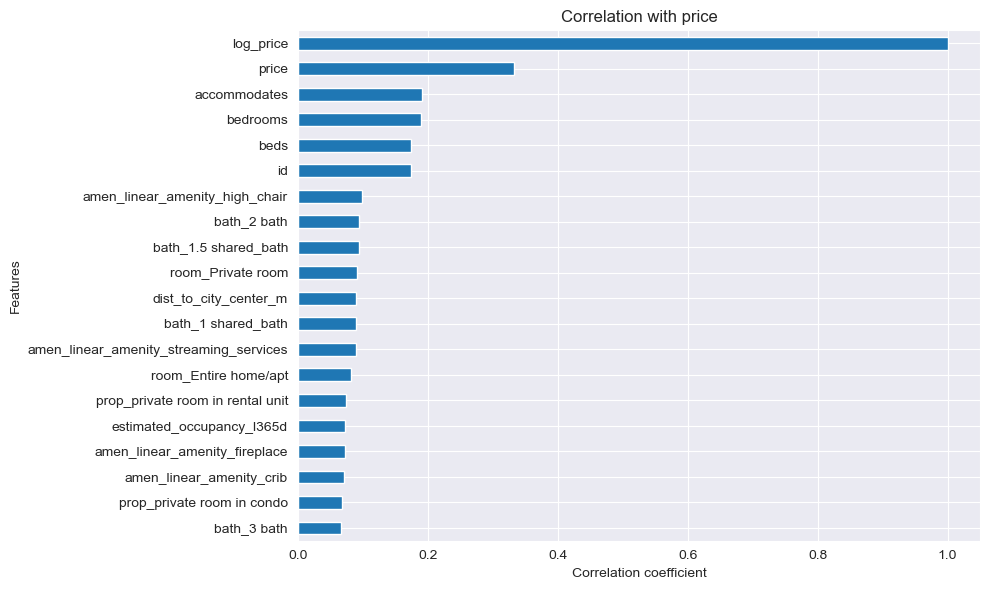

In [81]:
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

top_n = 20
corr_top = corr_sorted.head(top_n)

plt.figure(figsize=(10, 6))
corr_top[::-1].plot(kind="barh")

plt.title("Correlation with price")
plt.xlabel("Correlation coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [83]:
low_corr = corr_with_target[corr_with_target < 0.002].index.tolist()
print(len(low_corr), "features with very low correlation")

X_linear_reduced = df_full_linear.drop(columns=low_corr, errors="ignore")


21 features with very low correlation


In [82]:
cols = [c for c in df_full_linear.columns
        if df_full_linear[c].dtype != "O"
        and not c.startswith(("room_", "prop_", "neighbourhood_", "amen_", "bath_"))
        and c not in ("price", "log_price")]

X = df_full_linear[cols].apply(pd.to_numeric, errors="coerce").fillna(0)
corr = X.corr().abs()

for a in corr.columns:
    for b in corr.columns:
        if a < b and corr.loc[a, b] > 0.5:
            print(f"{a} - {b}: {corr.loc[a, b]:.3f}")


AttributeError: 'DataFrame' object has no attribute 'dtype'

In [95]:
df_test_line = df_full_linear.copy()
df_test_tr = df_full_tree.copy()

In [96]:
df_test_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9775 entries, 0 to 10074
Columns: 246 entries, id to amen_tree_amenity_xbox
dtypes: Int8(1), Sparse[float64, 0](153), bool(44), float64(15), int64(5), int8(28)
memory usage: 5.0 MB


In [97]:
to_drop_base = ["id", "price", "availability_ratio", "neighbourhood_cleansed"]

prefixes = ("room_", "prop_", "neighbourhood_", "bath_")
#"amen_"

prefix_cols = [
    c for c in df_test_tr.columns
    if c.startswith(prefixes)
]

cols_to_drop = to_drop_base + prefix_cols

df_test_line.drop(columns=cols_to_drop, inplace=True, errors="ignore")

df_test_tr.drop(columns=cols_to_drop, inplace=True, errors="ignore")


# Modeling

Now I start the modeling. The target is `log_price`. I use the log so that a few very expensive listings do not pull the model too much.

To judge a model I look at two things:
- R2 is how much of the price differences the model explains. 1.0 would be perfect and 0 means it is no better than always guessing the average price.
- MAE and RMSE are the average size of the errors, so lower is better.

I split the data into 70% train and 30% test, scale the columns for the linear models (Ridge and Lasso need that), and give the tree models the unscaled version.

In [98]:
df_model_line = df_test_line.copy()
df_model_tree = df_test_tr.copy()

### Test Train Split

In [99]:
target = "log_price"

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(df_model_line.drop(columns=[target]), df_model_line[target],test_size=0.3, random_state=1)

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(df_model_tree.drop(columns=[target]),df_model_tree[target],test_size=0.3, random_state=1)


In [90]:
scaler = StandardScaler()
X_train_lin = scaler.fit_transform(X_train_lin)
X_test_lin  = scaler.transform(X_test_lin)


/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


### Random Forest

In [100]:
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=300,max_depth=None, random_state=1)
rf.fit(X_train_tree, y_train_tree)

pred_rf = rf.predict(X_test_tree)
rmse = mean_squared_error(y_test_tree, pred_rf)
mae  = mean_absolute_error(y_test_tree, pred_rf)
r2   = r2_score(y_test_tree, pred_rf)
print(f"RandomForest"
      f" RMSE: {rmse:.4f} "
      f" MAE: {mae:.4f} "
      f"R²: {r2:.3f}")

feat_names = getattr(X_test_tree, "columns", np.array([f"f{i}" for i in range(X_test_tree.shape[1])]))
imp_mdi = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
print("\nImportances):")
print(imp_mdi.head(40).to_string())

perm = permutation_importance(
    rf, X_test_tree, y_test_tree,
    n_repeats=10, random_state=42, n_jobs=-1, scoring="neg_root_mean_squared_error"
)
imp_perm = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False)
print("\nPermutation importances):")
print(imp_perm.head(40).to_string())


/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


RandomForest RMSE: 0.2894  MAE: 0.4158 R²: 0.149

Importances):
dist_to_city_center_m                  0.084986
dist_to_region_centroid_m              0.069228
availability_365                       0.067279
longitude                              0.058751
latitude                               0.056089
accommodates                           0.045397
estimated_occupancy_l365d              0.044845
stay_flexibility                       0.036156
minimum_nights                         0.023905
maximum_nights                         0.018345
amen_tree_amenity_streaming_services   0.018142
occupancy_ratio                        0.015401
beds                                   0.014320
bedrooms                               0.012977
beds_per_bedroom                       0.012344
instant_bookable                       0.009152
amen_tree_amenity_elevator             0.008245
region_area_m2_right                   0.008217
region_area_m2_left                    0.008050
amen_tree_amenity_dryer_

/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: 

KeyboardInterrupt: 

In [58]:
from sklearn.linear_model import Ridge, Lasso


ridge = Ridge(alpha=0.5)
ridge.fit(X_train_lin, y_train_lin)

pred_ridge = ridge.predict(X_test_lin)
rmse = mean_squared_error(y_test_lin, pred_ridge)
mae = mean_absolute_error(y_test_lin, pred_ridge)
r2 = r2_score(y_test_lin, pred_ridge)

print(
    f"Ridge Regression"
    f"\n RMSE: {rmse:.4f}"
    f"\n MAE:  {mae:.4f}"
    f"\n R^2:  {r2:.3f}"
)

feat_names = getattr(
    X_test_tree,
    "columns",
    np.array([f"f{i}" for i in range(X_test_lin.shape[1])])
)

coef_ridge = pd.Series(ridge.coef_, index=feat_names)
print("\nCoefficients (Ridge):")
print(coef_ridge.head(40).to_string())

Ridge Regression
 RMSE: 0.3060
 MAE:  0.4306
 R^2:  0.100

Coefficients (Ridge):
latitude                                      0.018923
longitude                                    -0.006888
accommodates                                  0.037725
bedrooms                                      0.059744
beds                                         -0.003432
minimum_nights                               -0.015856
maximum_nights                               -0.015981
availability_365                              0.024302
estimated_occupancy_l365d                    -0.040703
instant_bookable                              0.026525
room_Entire home/apt                          0.004716
room_Hotel room                               0.012227
room_Private room                            -0.008207
room_Shared room                              0.008334
region_area_m2_left                           0.002929
dist_to_region_centroid_m                    -0.024314
dist_to_city_center_m                  

In [64]:

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_lin, y_train_lin)

pred_lasso = lasso.predict(X_test_lin)
rmse = mean_squared_error(y_test_lin, pred_lasso)
mae = mean_absolute_error(y_test_lin, pred_lasso)
r2 = r2_score(y_test_lin, pred_lasso)

print(
    f"Lasso Regression"
    f"\n RMSE: {rmse:.4f}"
    f"\n MAE:  {mae:.4f}"
    f"\n R^2:  {r2:.3f}"
)

feat_names = getattr(
    X_test_lin,
    "columns",
    np.array([f"f{i}" for i in range(X_test_lin.shape[1])])
)

coef_lasso = pd.Series(lasso.coef_, index=feat_names)
print("\nCoefficients (Lasso):")
print(coef_lasso.head(40).to_string())


Lasso Regression
 RMSE: 0.3050
 MAE:  0.4301
 R^2:  0.103

Coefficients (Lasso):
f0     0.000000
f1    -0.000000
f2     0.037588
f3     0.057660
f4     0.000000
f5    -0.015444
f6    -0.011088
f7     0.045740
f8    -0.039477
f9     0.026198
f10    0.000000
f11    0.011583
f12   -0.011589
f13    0.007555
f14    0.000000
f15   -0.020287
f16   -0.053042
f17    0.000000
f18   -0.008852
f19   -0.010045
f20   -0.011221
f21    0.000000
f22    0.016632
f23    0.016748
f24    0.000000
f25    0.000000
f26    0.001286
f27    0.006810
f28   -0.002459
f29    0.006716
f30    0.009609
f31   -0.009189
f32   -0.007069
f33    0.005952
f34   -0.013998
f35   -0.005306
f36   -0.020445
f37   -0.000391
f38   -0.004726
f39    0.014924


So did predicting price work? Not really. On the test set I got:

| Model | R2 |
|---|---|
| Random Forest | 0.15 |
| Ridge | 0.10 |
| Lasso | 0.10 |

An R2 of 0.10 to 0.15 means the features only explain about 10 to 15% of why one listing costs more than another. The rest the model cannot see. The strongest single feature was the distance to the city center, but even that has a weak effect.

The reason is the data, not the model. Everything I have here is a static fact about the listing. Real prices also move with the season, events, demand and how each host changes the price over time, and none of that is in this one month snapshot. So a fair price tool built only on this would mostly be guessing, which is why I do not want to present it as one.

One thing I would change: I dropped the neighbourhood column before modeling, which probably removed useful location signal. The cleaned up rerun in `src/regression_xai.py` keeps it and reaches about R2 0.53. Still not enough for pricing advice, but better.

# Bach Up Plan Idea

## Clustering

If I cannot say what a listing should cost, I can still say what kind of listing it is and what the market looks like overall. So from here I change the approach and use clustering: let the data group similar listings together, and then describe each group. No price promise, just a clearer picture of how the Amsterdam listings split up.

In [398]:
df_filled.columns.tolist()

['id',
 'latitude',
 'longitude',
 'price',
 'accommodates',
 'bedrooms',
 'beds',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'estimated_occupancy_l365d',
 'instant_bookable',
 'room_Entire home/apt',
 'room_Hotel room',
 'room_Private room',
 'room_Shared room',
 'prop_boat',
 'prop_entire condo',
 'prop_entire home',
 'prop_entire loft',
 'prop_entire rental unit',
 'prop_entire serviced apartment',
 'prop_entire townhouse',
 'prop_houseboat',
 'prop_other',
 'prop_private room in bed and breakfast',
 'prop_private room in condo',
 'prop_private room in home',
 'prop_private room in rental unit',
 'prop_room in boutique hotel',
 'prop_room in hotel',
 'bath_1 bath',
 'bath_1 private_bath',
 'bath_1 shared_bath',
 'bath_1.5 bath',
 'bath_1.5 shared_bath',
 'bath_2 bath',
 'bath_2.5 bath',
 'bath_3 bath',
 'bath_other',
 'log_price',
 'beds_per_bedroom',
 'occupancy_ratio',
 'stay_flexibility',
 'availability_ratio',
 'occupancy_ratio_target',
 'region_area_m2_left',
 

In [87]:
df_cluster = df_filled.copy()

In [88]:

core_numeric_cols = [
    "price",
    "log_price",
    "latitude",
    "longitude",
    "dist_to_city_center_m",
    "dist_to_region_centroid_m",
    "accommodates",
    "bedrooms",
    "beds",
    "beds_per_bedroom",
    "minimum_nights",
    "maximum_nights",
    "stay_flexibility",
    "occupancy_ratio",
    "region_area_m2",
]

room_cols = [c for c in df_cluster.columns if c.startswith("room_")]
prop_cols = [c for c in df_cluster.columns if c.startswith("prop_")]
bath_cols = [c for c in df_cluster.columns if c.startswith("bath_")]
geo_cols  = [c for c in df_cluster.columns if c.startswith("geo_")]

cluster_feature_cols = (
    core_numeric_cols
    + room_cols
    + prop_cols
    + bath_cols
    + geo_cols
)

cluster_feature_cols = [c for c in cluster_feature_cols if c in df_cluster.columns]

X_cluster = df_cluster[cluster_feature_cols].copy()


In [89]:
geo_cols = [c for c in df_cluster.columns if c.startswith("geo_")]
geo_cols = list(dict.fromkeys(geo_cols))

df_cluster["neighbourhood_ohe"] = (
    df_cluster[geo_cols]
    .idxmax(axis=1)
    .str.replace("geo_", "", regex=False)
)

df_cluster["median_price_neigh"] = (
    df_cluster.groupby("neighbourhood_ohe")["price"]
    .transform("median")
)

df_cluster["rel_price"] = (
    df_cluster["price"] / df_cluster["median_price_neigh"])

df_cluster["price_per_person"] = df_cluster["price"] / df_cluster["accommodates"].replace(0, np.nan)
df_cluster["price_per_person"] = df_cluster["price_per_person"].fillna(df_cluster["price"])

df_cluster["price_per_bed"] = df_cluster["price"] / df_cluster["beds"].replace(0, np.nan)
df_cluster["price_per_bed"] = df_cluster["price_per_bed"].fillna(df_cluster["price"])

df_cluster["price_normalized"] = df_cluster["price"] / (
    df_cluster["dist_to_city_center_m"].replace(0, np.nan)
)
df_cluster["price_normalized"] = df_cluster["price_normalized"].fillna(df_cluster["price"])

In [90]:
df_cluster = df_cluster[df_cluster["price"] < df_cluster["price"].quantile(0.99)]

df_cluster = df_cluster[df_cluster["rel_price"] < df_cluster["rel_price"].quantile(0.99)]

df_cluster = df_cluster[df_cluster["price_normalized"] < df_cluster["price_normalized"].quantile(0.99)]


In [91]:
numeric_cols = df_cluster.select_dtypes(include=["float64", "int64"]).columns.tolist()

geo_cols = [c for c in df_cluster.columns if c.startswith("geo_")]
geo_cols = list(dict.fromkeys(geo_cols))


numeric_cols = [
    c for c in numeric_cols
    if c not in geo_cols and c != "id"
]


print("Numeric features used for clustering:", len(numeric_cols))
print("Geo one-hot features:", len(geo_cols))


scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(df_cluster[numeric_cols])


X_scaled = np.hstack([
    scaled_numeric,
    df_cluster[geo_cols].values
])

print("X_scaled shape:", X_scaled.shape)


Numeric features used for clustering: 23
Geo one-hot features: 22
X_scaled shape: (9478, 45)


### PCA

I have a lot of numeric columns plus the amenity features. Clustering becomes unreliable with that many dimensions, because the points all start to look about equally far apart and the groups get blurry. PCA combines the columns into a few new ones that still hold most of the information, which gives KMeans an easier space to work in. I also use the first two components to draw the clusters on a 2D plot.

In [92]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=1)

X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_)


Shape after PCA: (9478, 3)
Explained variance: [0.19339867 0.14977566 0.10638037]


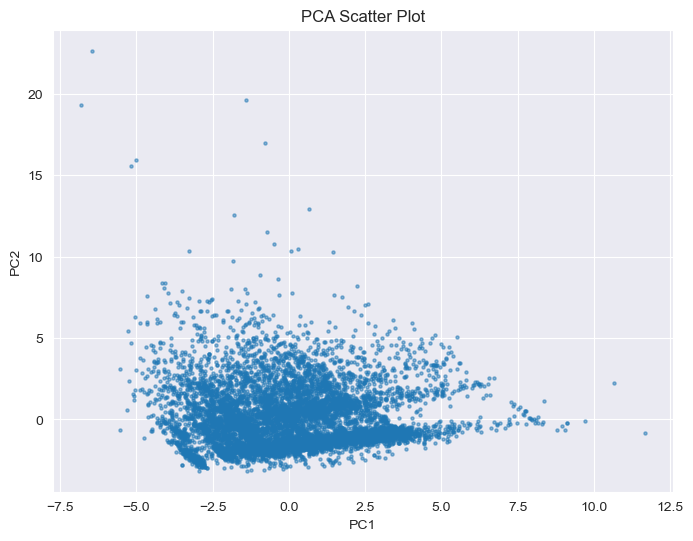

In [93]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot")
plt.show()


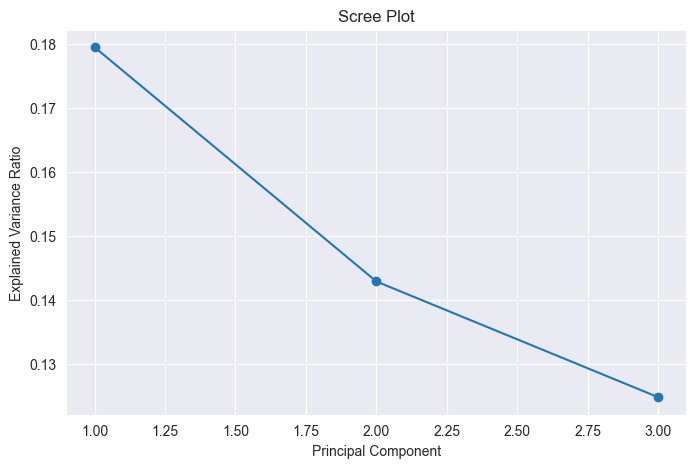

In [671]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_,
         marker='o')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()


I do not want to just assume KMeans is the right choice, so I run five methods on the same data: KMeans, Agglomerative, Gaussian Mixture, HDBSCAN and Spectral. Each one makes different assumptions about the shape of a cluster, so comparing them shows which one actually fits this data best. I do that comparison a few cells below.

### KMeans

In [94]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4,n_init=20,random_state=42)

clusters = kmeans.fit_predict(X_pca)

df_cluster["cluster_km"] = clusters

df_cluster["cluster_km"].value_counts()

cluster_km
1    3557
3    2710
0    1749
2    1462
Name: count, dtype: int64

In [673]:
df_cluster.groupby("cluster_km")[[
    "price",
    "rel_price",
    "price_per_person",
    "price_per_bed",
    "dist_to_city_center_m"
]].median().sort_values("price")


,price,rel_price,price_per_person,price_per_bed,dist_to_city_center_m
cluster_km,,,,,
1,120.000000,0.666667,45.000000,90.000000,2404.970239
2,160.000000,0.888889,60.000000,120.000000,1940.465923
0,183.000000,1.176471,45.000000,60.000000,5053.446057
3,250.000000,1.438889,97.500000,185.000000,2023.450206


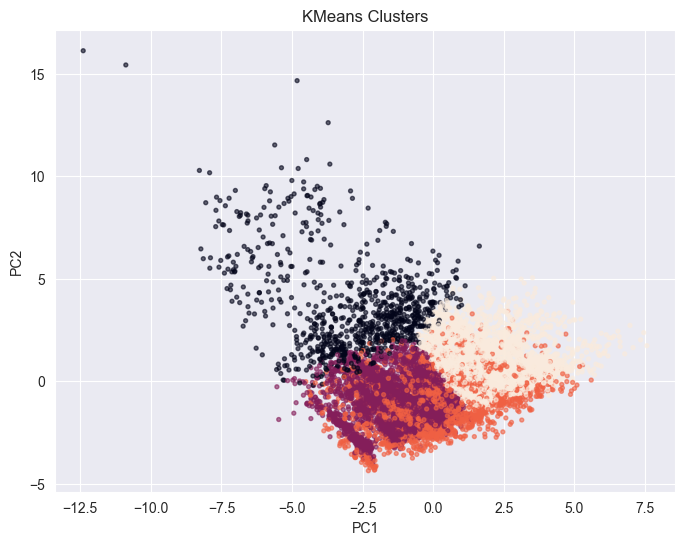

In [674]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_cluster["cluster_km"],
    s=8,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters")
plt.show()


### AgglomerativeClustering

In [95]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt


agg = AgglomerativeClustering(n_clusters=4,linkage="ward")KMeans AgglomerativeClustering

df_cluster["cluster_agg"] = agg.fit_predict(X_pca)

print(df_cluster["cluster_agg"].value_counts())

cluster_agg
1    3450
0    2512
2    2392
3    1124
Name: count, dtype: int64


In [525]:
agg_summary = df_cluster.groupby("cluster_agg")[[
    "price",
    "rel_price",
    "price_per_person",
    "price_per_bed",
    "dist_to_city_center_m"
]].median().sort_values("price")

agg_summary


,price,rel_price,price_per_person,price_per_bed,dist_to_city_center_m
cluster_agg,,,,,
3,110.000000,0.647059,45.000000,80.000000,2419.094181
2,150.000000,0.972222,37.500000,57.500000,5195.171291
0,183.000000,1.048711,70.000000,125.000000,1875.966949
1,230.000000,1.318052,87.500000,160.000000,2106.447582


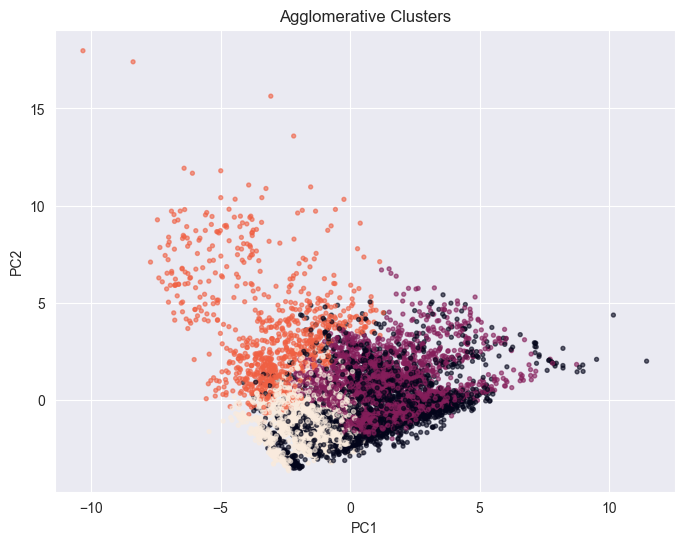

In [526]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_cluster["cluster_agg"],
    s=8,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative Clusters")
plt.show()


### GaussianMixture

In [96]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, covariance_type="full",random_state=1,n_init=5)

gmm_labels = gmm.fit_predict(X_pca)
gmm_proba = gmm.predict_proba(X_pca)

df_cluster["cluster_gmm"] = gmm_labels
df_cluster["cluster_gmm_conf"] = gmm_proba.max(axis=1)

print(df_cluster["cluster_gmm"].value_counts())


cluster_gmm
0    3677
2    3201
3    1924
1     676
Name: count, dtype: int64


In [495]:
gmm_summary = df_cluster.groupby("cluster_gmm")[[
    "price",
    "rel_price",
    "price_per_person",
    "price_per_bed",
    "dist_to_city_center_m"
]].median().sort_values("price")

gmm_summary


,price,rel_price,price_per_person,price_per_bed,dist_to_city_center_m
cluster_gmm4,,,,,
0,160.000000,0.941176,61.000000,120.000000,1933.849929
1,175.000000,1.000000,60.000000,120.000000,2324.083446
2,195.000000,1.228758,45.000000,60.000000,5195.448064


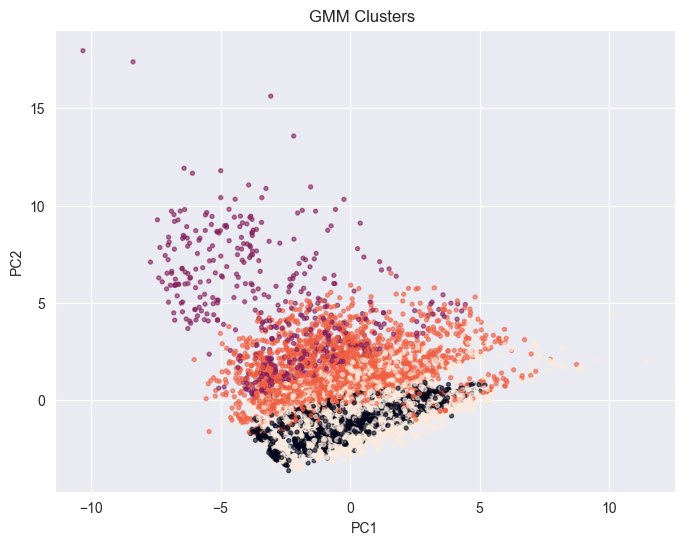

In [528]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_cluster["cluster_gmm"],
    s=8,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters ")
plt.show()


### HDBSCAN

In [101]:
import hdbscan

hdb = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=20,
    cluster_selection_method="eom"
)

hdb_labels = hdb.fit_predict(X_pca)
df_cluster["cluster_hdb"] = hdb_labels

print(df_cluster["cluster_hdb"].value_counts().sort_index())

mask_hdb = df_cluster["cluster_hdb"] != -1

hdb_summary = df_cluster[mask_hdb].groupby("cluster_hdb")[[
    "price",
    "rel_price",
    "price_per_person",
    "price_per_bed",
    "dist_to_city_center_m"
]].median().sort_values("price")

hdb_summary





/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ruslan/miniconda3/envs/individual/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


cluster_hdb
-1    4035
 0    5315
 1     128
Name: count, dtype: int64


,price,rel_price,price_per_person,price_per_bed,dist_to_city_center_m
cluster_hdb,,,,,
1,40.0,0.222222,20.0,40.0,2219.362664
0,160.0,0.888889,62.5,120.0,2144.772231


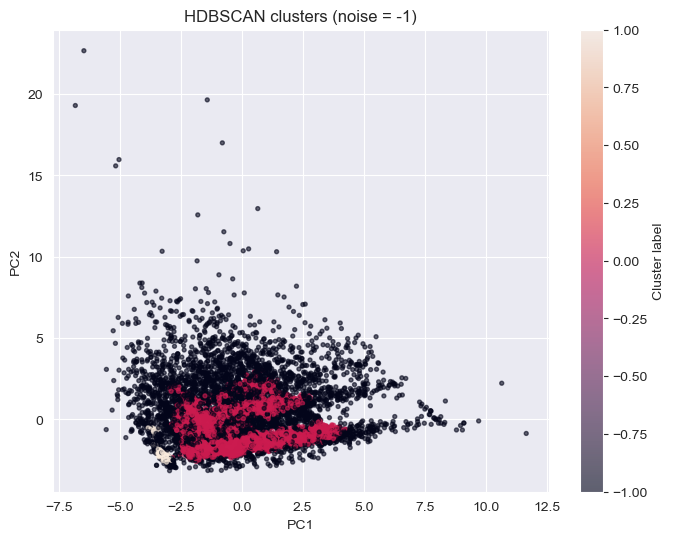

In [102]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_cluster["cluster_hdb"],
    s=8,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("HDBSCAN clusters (noise = -1)")
plt.colorbar(label="Cluster label")
plt.show()

### Spectral Clustering

In [98]:
from sklearn.cluster import SpectralClustering

spec = SpectralClustering(
    n_clusters=4,
    affinity="nearest_neighbors",
    n_neighbors=100,
    random_state=1,
    assign_labels="kmeans"
)

spec_labels = spec.fit_predict(X_pca)
df_cluster["cluster_spec"] = spec_labels

print(df_cluster["cluster_spec"].value_counts())

spec_summary = df_cluster.groupby("cluster_spec")[[
    "price",
    "rel_price",
    "price_per_person",
    "price_per_bed",
    "dist_to_city_center_m"
]].median().sort_values("price")

spec_summary



cluster_spec
0    3297
3    2337
1    2270
2    1574
Name: count, dtype: int64


,price,rel_price,price_per_person,price_per_bed,dist_to_city_center_m
cluster_spec,,,,,
3,115.0,0.655738,54.0,100.0,2416.396904
1,135.0,0.777778,60.0,115.0,1798.696910
0,225.0,1.280000,57.5,90.0,2757.819290
2,245.0,1.388889,117.5,240.0,1914.751849


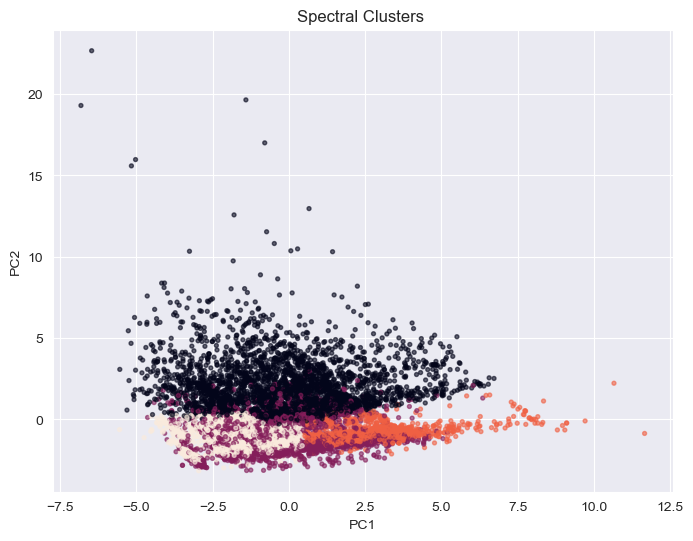

In [103]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_cluster["cluster_spec"],
    s=8,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spectral Clusters ")
plt.show()


### Comparison

I compare the methods with three scores instead of trusting a single number. In short:
- Silhouette: how well each point fits its own cluster compared to the nearest other cluster. It runs from about -1 to 1, higher is better.
- Davies-Bouldin: the average overlap between a cluster and its most similar neighbour. Lower is better, 0 would mean perfectly separated clusters.
- Calinski-Harabasz: how far apart the clusters are compared to how tight they are inside. Higher is better.

If one method wins on all three, that is a good sign it fits the data best.

In [99]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

clusterings = {
    "KMeans": df_cluster["cluster_km"],
    "Agglomerative": df_cluster["cluster_agg"],
    "GMM": df_cluster["cluster_gmm"],
    "Spectral": df_cluster["cluster_spec"]
}

results = []

for name, labels in clusterings.items():
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    results.append([name, sil, db, ch])

df_metrics = pd.DataFrame(results, columns=["model", "silhouette", "davies_bouldin", "calinski_harabasz"])
df_metrics

pd.DataFrame(results).T


,0,1,2,3
0,KMeans,Agglomerative,GMM,Spectral
1,0.121868,0.09723,0.063387,0.064704
2,2.150249,2.473902,2.946168,2.194734
3,1047.479581,836.619474,563.819816,878.294928


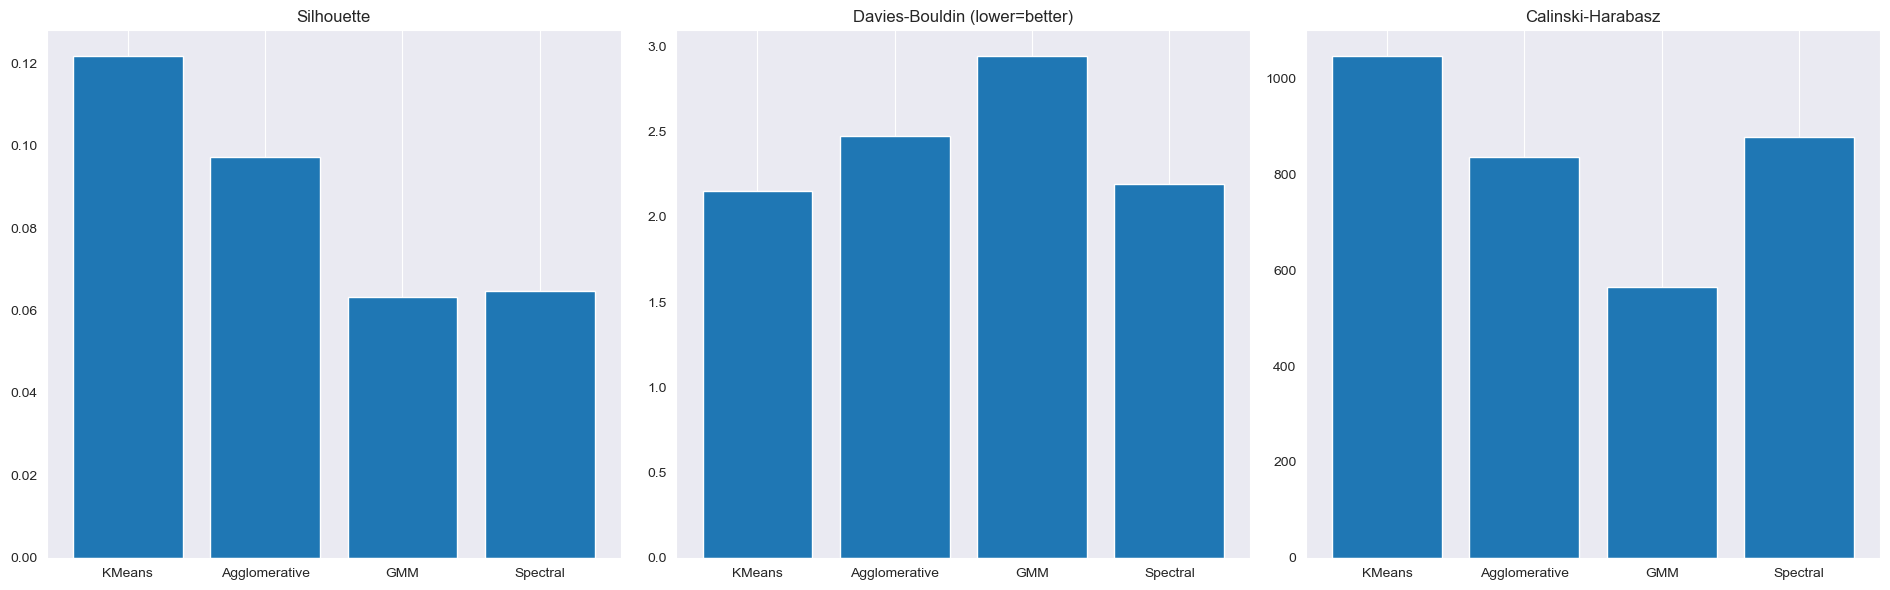

In [100]:
plt.figure(figsize=(19, 6))

plt.subplot(1,3,1)
plt.bar(df_metrics["model"], df_metrics["silhouette"])
plt.title("Silhouette")
plt.grid(axis="y")

plt.subplot(1,3,2)
plt.bar(df_metrics["model"], df_metrics["davies_bouldin"])
plt.title("Davies-Bouldin (lower=better)")
plt.grid(axis="y")

plt.subplot(1,3,3)
plt.bar(df_metrics["model"], df_metrics["calinski_harabasz"])
plt.title("Calinski-Harabasz")
plt.grid(axis="y")

plt.tight_layout()
plt.show()


KMeans came out best on all three scores:

| Model | Silhouette | Davies-Bouldin | Calinski-Harabasz |
|---|---|---|---|
| KMeans | 0.12 | 2.15 | 1047 |
| Agglomerative | 0.10 | 2.47 | 837 |
| Spectral | 0.06 | 2.19 | 878 |
| GMM | 0.06 | 2.95 | 564 |

I should be honest that a silhouette of 0.12 is low. The clusters overlap quite a bit, they are not clean separated groups. So KMeans is the best option here, but the grouping is soft rather than sharp. I use KMeans for the final segments and keep that limitation in mind.

### Finalizing KMeans

By finalizing I mean turning the raw KMeans output into something I can actually read. The model only gives each listing a cluster number like 0, 1, 2, 3, which means nothing on its own. So I sort the clusters by their median price and give them names (low, mid, upper_mid, high) so the rest of the analysis can talk about them clearly.

In [546]:
km_summary = (
    df_cluster
    .groupby("cluster")["price"]
    .median()
    .sort_values())

print(km_summary)

ordered_clusters = km_summary.index.tolist()

segment_map = {
    ordered_clusters[0]: "low",
    ordered_clusters[1]: "mid",
    ordered_clusters[2]: "upper_mid",
    ordered_clusters[3]: "high",
}

df_cluster["price_segment"] = df_cluster["cluster"].map(segment_map)
df_cluster[["cluster", "price", "price_segment"]].head()


cluster
0   120.000000
3   160.000000
1   188.500000
2   259.000000
Name: price, dtype: float64


,cluster,price,price_segment
0,0,89.000000,low
1,3,155.000000,mid
2,3,79.000000,mid
3,3,55.000000,mid
4,2,240.000000,high


In [547]:
segments_order = (
    df_cluster
    .groupby("price_segment")["price"]
    .median()
    .sort_values()
    .index
    .tolist()
)

print("Segments order (cheap - expensive):", segments_order)

segment_profile = (
    df_cluster
    .groupby("price_segment")[[
        "price",
        "rel_price",
        "price_per_person",
        "price_per_bed",
        "dist_to_city_center_m",
        "estimated_occupancy_l365d",
        "accommodates",
        "beds",
        "bedrooms"
    ]]
    .median()
    .loc[segments_order]
    .round(2)
)

segment_profile


Segments order (cheap - expensive): ['low', 'mid', 'upper_mid', 'high']


,price,rel_price,price_per_person,price_per_bed,dist_to_city_center_m,estimated_occupancy_l365d,accommodates,beds,bedrooms
price_segment,,,,,,,,,
low,120.000000,0.670000,47.500000,90.000000,2400.560000,16.000000,2.000000,1.000000,1.000000
mid,160.000000,0.890000,60.000000,117.000000,1967.330000,55.000000,2.000000,1.000000,1.000000
upper_mid,188.500000,1.180000,45.000000,60.000000,5056.650000,16.000000,4.000000,3.000000,3.000000
high,259.000000,1.530000,100.000000,200.000000,1915.830000,20.000000,2.000000,1.000000,1.000000


In [551]:
segment_medians = (
    df_cluster
    .groupby("price_segment")["price"]
    .median()
    .to_dict()
)

segment_medians




{'high': 259.0, 'low': 120.0, 'mid': 160.0, 'upper_mid': 188.5}

In [552]:
df_cluster["seg_rel_price"] = (
    df_cluster["price"] /
    df_cluster["price_segment"].map(segment_medians)
)


In [553]:
def categorize_relative_price(x):
    if x < 0.85:
        return "underpriced"
    elif x > 1.15:
        return "overpriced"
    else:
        return "fair"

df_cluster["fairness_label"] = df_cluster["seg_rel_price"].apply(categorize_relative_price)


In [554]:
df_cluster["fairness_label"].value_counts(normalize=True).round(3)

fairness_label
fair          0.372000
overpriced    0.336000
underpriced   0.292000
Name: proportion, dtype: float64

In [555]:
df_cluster.groupby("fairness_label")["seg_rel_price"].median()


fairness_label
fair          1.000000
overpriced    1.406250
underpriced   0.687500
Name: seg_rel_price, dtype: float64

After naming the segments I also wanted to flag whether a single listing looks cheap or expensive for its own segment. So for each listing I take its price divided by the median price of its segment, and label it underpriced, fair or overpriced. The split came out at about 29% underpriced, 37% fair and 34% overpriced, which tells me roughly a third of listings sit far from what is normal for their group.

I have to be honest about a weakness here though. The segments were built partly from price related columns, so comparing a listing's price to its segment's price is close to comparing price with itself. It looks like an insight but it is mostly built in by how I made the clusters. I keep it because it was my original idea, but in the cleaned up version I drop this label and cluster on structural features only, with no price involved.

### Visualizations

Now a few plots to see the result: where the segments and the fairness labels sit by price and location, and how the property and room types split across the segments. This is mostly to check that the groups make sense and are not just random.

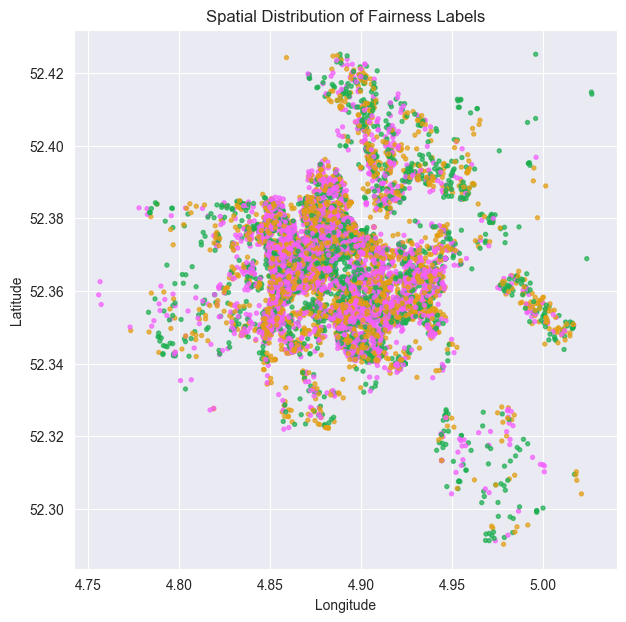

In [566]:
plt.figure(figsize=(7, 7))

colors = {
    "underpriced": "#1CAF50",
    "fair": "#F55FFF",
    "overpriced": "#E39E13"
}

plt.scatter(
    df_cluster["longitude"],
    df_cluster["latitude"],
    c=df_cluster["fairness_label"].map(colors),
    s=8,
    alpha=0.7
)

plt.title("Spatial Distribution of Fairness Labels")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


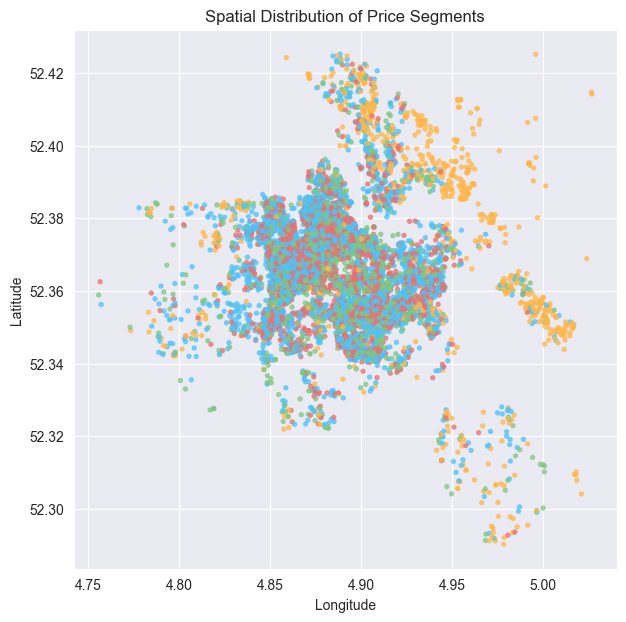

In [568]:
plt.figure(figsize=(6, 7))

seg_colors = {
    "low": "#4FC3F7",
    "mid": "#81C784",
    "upper_mid": "#FFB74D",
    "high": "#E57373"
}

plt.scatter(
    df_cluster["longitude"],
    df_cluster["latitude"],
    c=df_cluster["price_segment"].map(seg_colors),
    s=8,
    alpha=0.7
)

plt.title("Spatial Distribution of Price Segments")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


/var/folders/kf/d6_rnqqd78b0c445btm4gpgc0000gn/T/ipykernel_3440/85024428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="price_segment", y="price", data=df_cluster, palette="Set3")


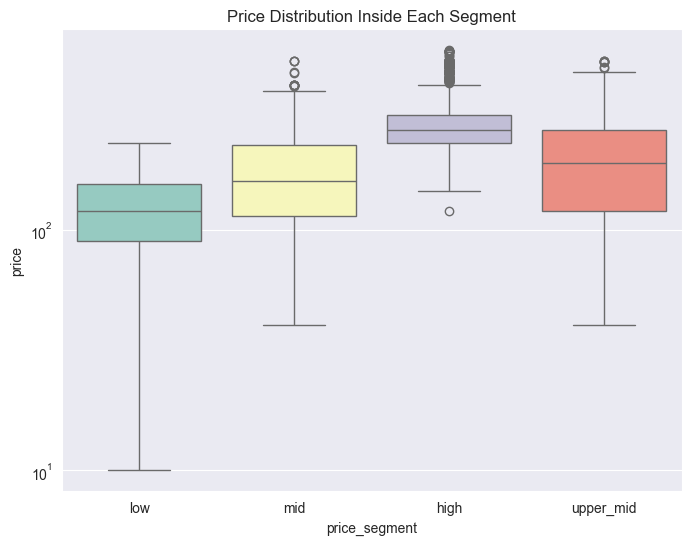

/var/folders/kf/d6_rnqqd78b0c445btm4gpgc0000gn/T/ipykernel_3440/85024428.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="fairness_label", y="seg_rel_price", data=df_cluster, palette="coolwarm")


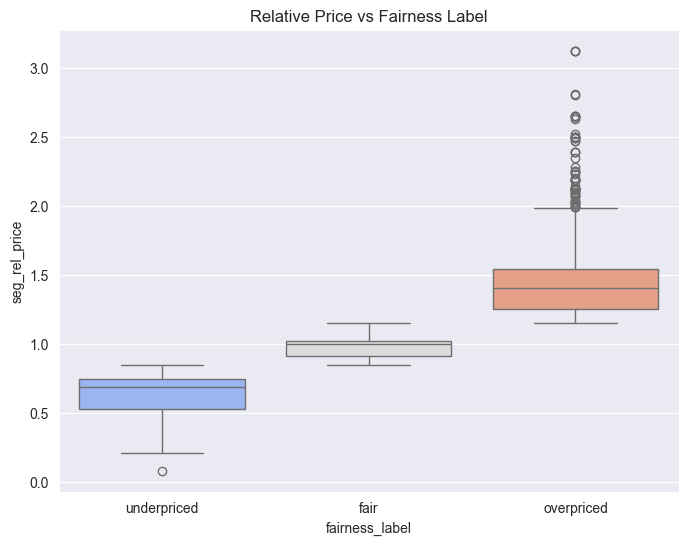

In [571]:
plt.figure(figsize=(8,6))
sns.boxplot(x="price_segment", y="price", data=df_cluster, palette="Set3")
plt.title("Price Distribution Inside Each Segment")
plt.yscale("log")
plt.show()


plt.figure(figsize=(8,6))
sns.boxplot(x="fairness_label", y="seg_rel_price", data=df_cluster, palette="coolwarm")
plt.title("Relative Price vs Fairness Label")
plt.show()


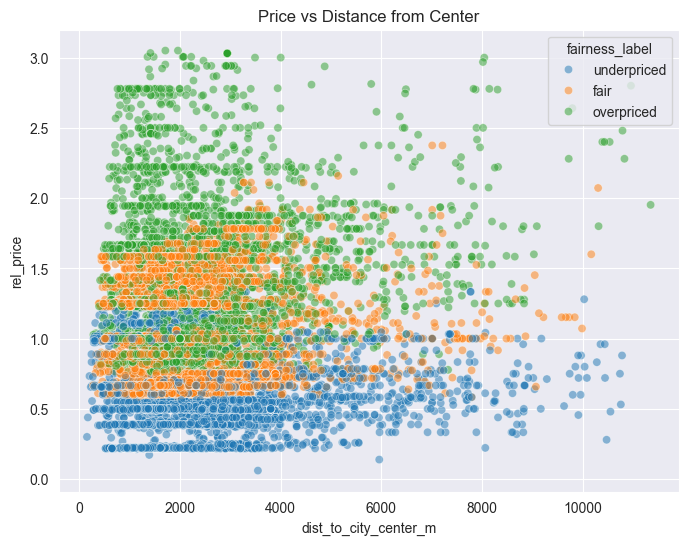

In [575]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_cluster,
    x="dist_to_city_center_m",
    y="rel_price",
    hue="fairness_label",
    alpha=0.5
)
plt.title("Price vs Distance from Center")
plt.show()


In [577]:
seg_fair_table = (
    pd.crosstab(df_cluster["price_segment"], df_cluster["fairness_label"], normalize="index")
    .round(3)
    .sort_index()
)

seg_fair_table

fairness_label,fair,overpriced,underpriced
price_segment,,,
high,0.528000,0.335000,0.137000
low,0.366000,0.321000,0.313000
mid,0.248000,0.323000,0.428000
upper_mid,0.165000,0.440000,0.395000


In [579]:
prop_cols = [c for c in df_cluster.columns if c.startswith("prop_")]

rows = []
for col in prop_cols:
    mask = df_cluster[col] == 1
    n_total = mask.sum()
    if n_total < 50:
        continue

    n_over = ((df_cluster["fairness_label"] == "overpriced") & mask).sum()
    n_under = ((df_cluster["fairness_label"] == "underpriced") & mask).sum()
    n_fair = ((df_cluster["fairness_label"] == "fair") & mask).sum()

    rows.append({
        "property_type": col.replace("prop_", ""),
        "total_listings": n_total,
        "overpriced_share": n_over / n_total,
        "fair_share": n_fair / n_total,
        "underpriced_share": n_under / n_total,
    })

prop_fair_df = (
    pd.DataFrame(rows)
    .sort_values("overpriced_share", ascending=False)
    .round(3)
)

prop_fair_df


,property_type,total_listings,overpriced_share,fair_share,underpriced_share
5,entire serviced apartment,91,0.615000,0.077000,0.308000
0,boat,110,0.545000,0.227000,0.227000
6,entire townhouse,216,0.500000,0.329000,0.171000
7,houseboat,172,0.494000,0.360000,0.145000
13,room in boutique hotel,85,0.435000,0.400000,0.165000
2,entire home,1010,0.415000,0.258000,0.327000
3,entire loft,226,0.376000,0.398000,0.226000
4,entire rental unit,4225,0.337000,0.398000,0.265000
8,other,568,0.303000,0.317000,0.380000
1,entire condo,1692,0.299000,0.457000,0.243000


In [584]:
room_cols = [c for c in df_cluster.columns if c.startswith("room_")]

rows = []
for col in room_cols:
    mask = df_cluster[col] == 1
    n_total = mask.sum()
    if n_total < 0:
        continue

    n_over = ((df_cluster["fairness_label"] == "overpriced") & mask).sum()
    n_under = ((df_cluster["fairness_label"] == "underpriced") & mask).sum()
    n_fair = ((df_cluster["fairness_label"] == "fair") & mask).sum()

    rows.append({
        "room_type": col.replace("room_", ""),
        "total_listings": n_total,
        "overpriced_share": n_over / n_total,
        "fair_share": n_fair / n_total,
        "underpriced_share": n_under / n_total,
    })

room_fair_df = (
    pd.DataFrame(rows)
    .sort_values("overpriced_share", ascending=False)
    .round(3)
)

room_fair_df


,room_type,total_listings,overpriced_share,fair_share,underpriced_share
1,Hotel room,32,0.469000,0.312000,0.219000
0,Entire home/apt,7888,0.353000,0.383000,0.264000
2,Private room,1532,0.251000,0.314000,0.435000
3,Shared room,26,0.077000,0.577000,0.346000


# Export

Last step. I save the parts the rest of the project needs: the scaler, the PCA, the KMeans model and a small JSON file. That way the web demo can load them directly instead of running this whole notebook again.

In [647]:
import joblib

joblib.dump(scaler, "../archive/scaler.pkl")
joblib.dump(pca, "../archive/pca.pkl")
joblib.dump(kmeans, "../archive/kmeans.pkl")


['kmeans.pkl']

In [648]:
feature_list = df_cluster.columns.tolist()


In [649]:
df_cluster.columns.tolist()


['id',
 'latitude',
 'longitude',
 'price',
 'accommodates',
 'bedrooms',
 'beds',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'estimated_occupancy_l365d',
 'instant_bookable',
 'room_Entire home/apt',
 'room_Hotel room',
 'room_Private room',
 'room_Shared room',
 'prop_boat',
 'prop_entire condo',
 'prop_entire home',
 'prop_entire loft',
 'prop_entire rental unit',
 'prop_entire serviced apartment',
 'prop_entire townhouse',
 'prop_houseboat',
 'prop_other',
 'prop_private room in bed and breakfast',
 'prop_private room in condo',
 'prop_private room in home',
 'prop_private room in rental unit',
 'prop_room in boutique hotel',
 'prop_room in hotel',
 'bath_1 bath',
 'bath_1 private_bath',
 'bath_1 shared_bath',
 'bath_1.5 bath',
 'bath_1.5 shared_bath',
 'bath_2 bath',
 'bath_2.5 bath',
 'bath_3 bath',
 'bath_other',
 'log_price',
 'beds_per_bedroom',
 'occupancy_ratio',
 'stay_flexibility',
 'availability_ratio',
 'occupancy_ratio_target',
 'region_area_m2_left',
 